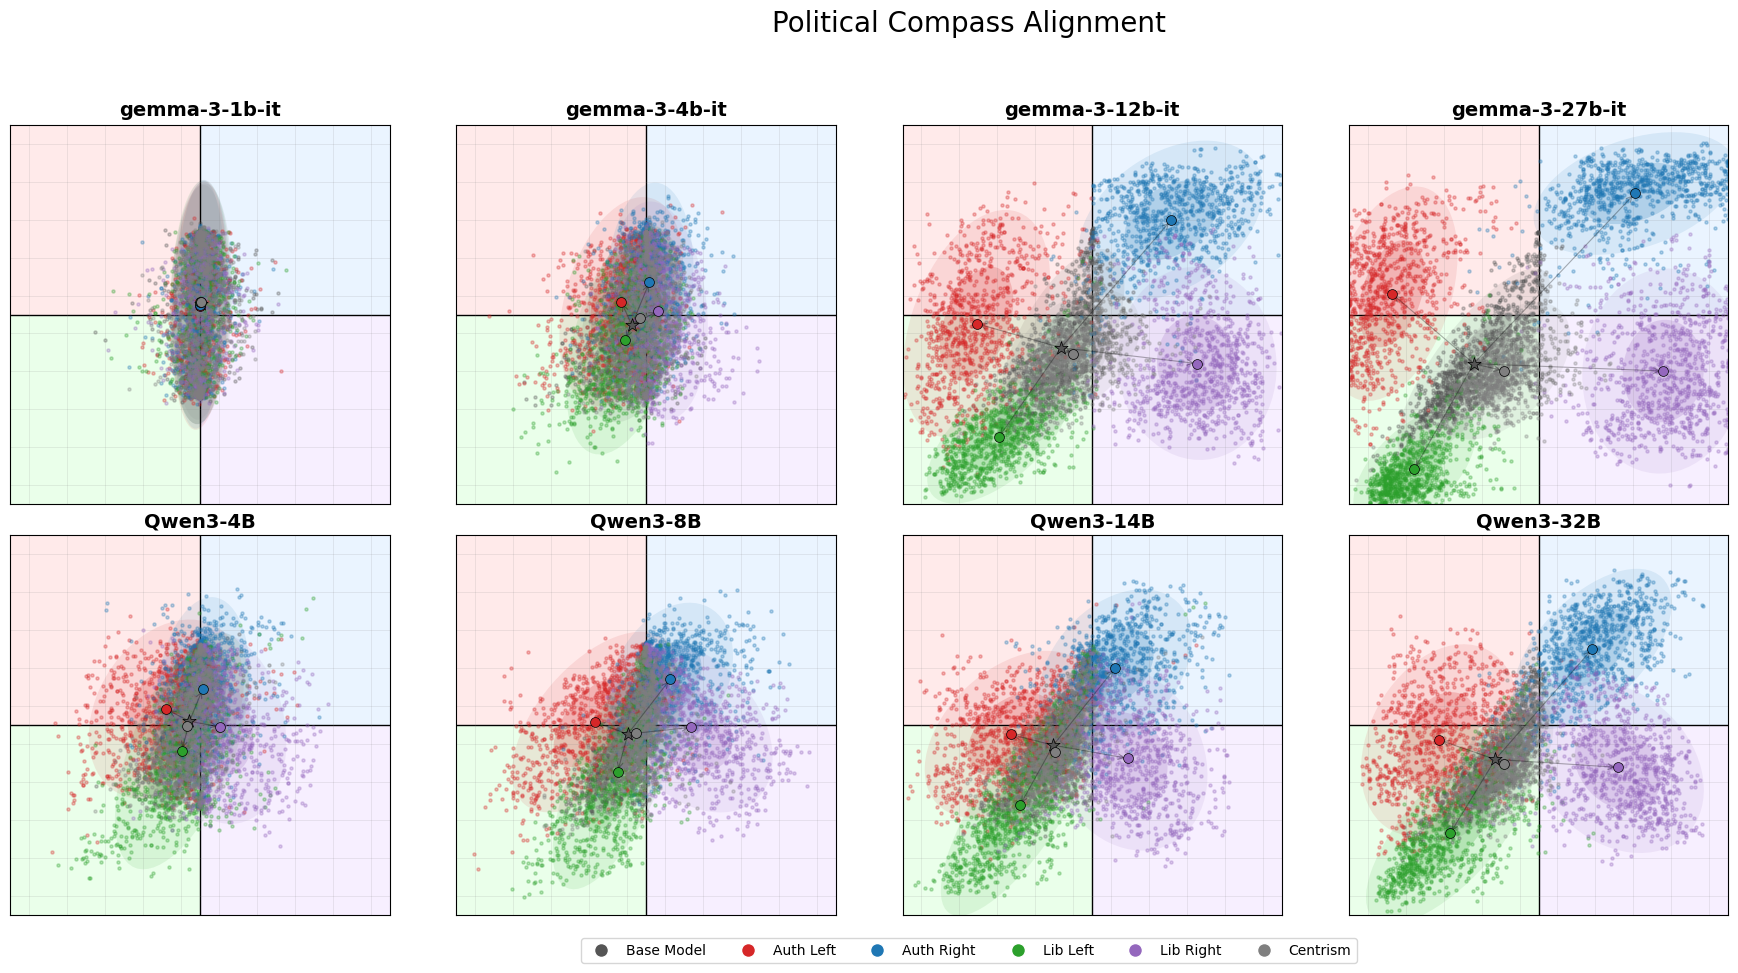

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

# ==========================================
# CONFIGURATION
# ==========================================
RESULTS_DIR = "output/mcq-v1-300/results/"
PARAMS_PATH = "scorer.npz"
PLOTS_OUTPUT_DIR = "./output/mcq-v1-300/plots/"

FINAL_MODELS = [
    # Gemma-3 Family
    'gemma-3-1b-it',
    'gemma-3-4b-it',
    'gemma-3-12b-it',
    'gemma-3-27b-it',
    # Qwen-3 Family
    'Qwen3-4B',
    'Qwen3-8B',
    'Qwen3-14B',
    'Qwen3-32B',
]

TARGET_IDEOLOGIES = ["base", "authoritarian_left", "authoritarian_right", "libertarian_left", "libertarian_right", "centrism"]
DISPLAY_NAMES = {
    "base": "Base Model",
    "authoritarian_left": "Auth Left",
    "authoritarian_right": "Auth Right",
    "libertarian_left": "Lib Left",
    "libertarian_right": "Lib Right",
    "centrism": "Centrism"
}
COLORS = {
    "Base Model": "#555555",
    "Auth Left":  "#d62728",
    "Auth Right": "#1f77b4",
    "Lib Left":   "#2ca02c",
    "Lib Right":  "#9467bd",
    "Centrism":   "#7f7f7f"
}

# ==========================================
# HELPER FUNCTIONS
# ==========================================

def confidence_ellipse(x, y, ax, n_std=1.0, facecolor='none', **kwargs):
    if x.size != y.size:
        raise ValueError("x and y must be the same size")

    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    
    # Eigendecomposition gives correct axis orientation
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    
    # Sort by descending eigenvalue
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    
    # Angle of the largest eigenvector
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    
    # Width and height are 2 * n_std * sqrt(eigenvalue)
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    
    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=angle,
        facecolor=facecolor,
        **kwargs
    )
    
    return ax.add_patch(ellipse)

def draw_background(ax):
    ax.set_xlim(-10, 10); ax.set_ylim(-10, 10); ax.set_aspect('equal')
    ax.add_patch(patches.Rectangle((-10, 0), 10, 10, fc='#ff3333', alpha=0.1)) 
    ax.add_patch(patches.Rectangle((0, 0), 10, 10, fc='#3399ff', alpha=0.1))   
    ax.add_patch(patches.Rectangle((-10, -10), 10, 10, fc='#33ff33', alpha=0.1)) 
    ax.add_patch(patches.Rectangle((0, -10), 10, 10, fc='#b366ff', alpha=0.1))   
    ax.axhline(0, color='black', lw=1); ax.axvline(0, color='black', lw=1)
    for i in range(-9, 10, 2):
        if i != 0:
            ax.axhline(i, color='gray', lw=0.5, alpha=0.2)
            ax.axvline(i, color='gray', lw=0.5, alpha=0.2)
    ax.set_xticks([]); ax.set_yticks([])

# ==========================================
# DATA PROCESSING (Reused from your snippet)
# ==========================================

def calculate_scores_with_debias(df, W_ECON, W_SOC, B_ECON, B_SOC, NUM_QUESTIONS):
    econ_scores = np.zeros(len(df)) + B_ECON
    soc_scores = np.zeros(len(df)) + B_SOC
    is_reversed = df['perm_id'].isin([2, 3]).values
    
    for q_idx in range(NUM_QUESTIONS):
        cols = [f"q{q_idx}_prob_ans{a}" for a in range(4)]
        if not all(c in df.columns for c in cols): continue
        probs = df[cols].values
        corrected_probs = probs.copy()
        corrected_probs[is_reversed] = probs[is_reversed][:, ::-1]
        econ_scores += np.dot(corrected_probs, W_ECON[q_idx, :])
        soc_scores += np.dot(corrected_probs, W_SOC[q_idx, :])
        
    df['score_econ'] = econ_scores
    df['score_soc'] = soc_scores
    return df

def process_and_plot_grid():
    # 1. Load Parameters
    try:
        loaded_params = np.load(PARAMS_PATH)
        W_ECON, W_SOC = loaded_params['weights_economic'], loaded_params['weights_social']
        B_ECON, B_SOC = loaded_params['bias_economic'], loaded_params['bias_social']
        NUM_QUESTIONS = W_ECON.shape[0]
    except Exception as e:
        print(f"Error loading parameters: {e}"); return

    # 2. Load Data
    all_files = [os.path.join(RESULTS_DIR, f) for f in os.listdir(RESULTS_DIR) if f.endswith(".csv")]
    if not all_files: print("No CSV files found."); return
        
    df_raw = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
    
    # 3. Filter and Calculate
    df = df_raw[df_raw['model'].isin(FINAL_MODELS)].copy()
    df = calculate_scores_with_debias(df, W_ECON, W_SOC, B_ECON, B_SOC, NUM_QUESTIONS)
    df['Label'] = df['ideology'].map(DISPLAY_NAMES)

    # 4. Create Grid Plot
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i, model_name in enumerate(FINAL_MODELS):
        ax = axes[i]
        draw_background(ax)
        ax.set_title(model_name, fontsize=14, fontweight='bold')
        
        model_df = df[df['model'] == model_name]
        if model_df.empty:
            ax.text(0, 0, "No Data", ha='center')
            continue

        # Get Base Model position for arrows
        try:
            base_subset = model_df[model_df['Label'] == 'Base Model']
            bx, by = base_subset['score_econ'].mean(), base_subset['score_soc'].mean()
        except:
            bx, by = 0, 0

        for label, color in COLORS.items():
            subset = model_df[model_df['Label'] == label]
            if subset.empty: continue
            
            x, y = subset['score_econ'].values, subset['score_soc'].values
            m_x, m_y = x.mean(), y.mean()

            # Plot raw scatter cloud
            ax.scatter(x, y, color=color, s=5, alpha=0.3, zorder=2)
            
            # Plot Tilted Confidence Ellipse (2 Standard Deviations)
            if len(subset) > 2: # Need at least a few points for covariance
                try:
                    confidence_ellipse(x, y, ax, n_std=1.0, facecolor=color, alpha=0.2, zorder=1)
                    confidence_ellipse(x, y, ax, n_std=2.0, facecolor=color, alpha=0.1, zorder=1)
                except:
                    pass # Handle singular matrices if data is perfectly linear
            
            # Centroid
            ax.scatter(m_x, m_y, color=color, s=100 if label=="Base Model" else 50, 
                       marker='*' if label=="Base Model" else 'o', edgecolors='black', linewidths=0.5, zorder=5)
            
            # Arrow from Base
            if label != "Base Model":
                ax.annotate("", xy=(m_x, m_y), xytext=(bx, by),
                            arrowprops=dict(arrowstyle="->", color='black', lw=0.8, alpha=0.3), zorder=3)

    # Shared Legend
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=l) 
               for l, c in COLORS.items()]
    fig.legend(handles=handles, loc='lower center', ncol=6, bbox_to_anchor=(0.5, 0.02), frameon=True)
    
    fname = "Political Compass Alignment"
    plt.suptitle(fname, fontsize=20, y=0.98)
    plt.savefig(os.path.join(PLOTS_OUTPUT_DIR, "Political_Compass_Alignment" + ".png"), dpi=150)
    plt.tight_layout(rect=[0, 0.06, 0.9, 0.94], h_pad=1.5)
    plt.show()

if __name__ == "__main__":
    process_and_plot_grid()

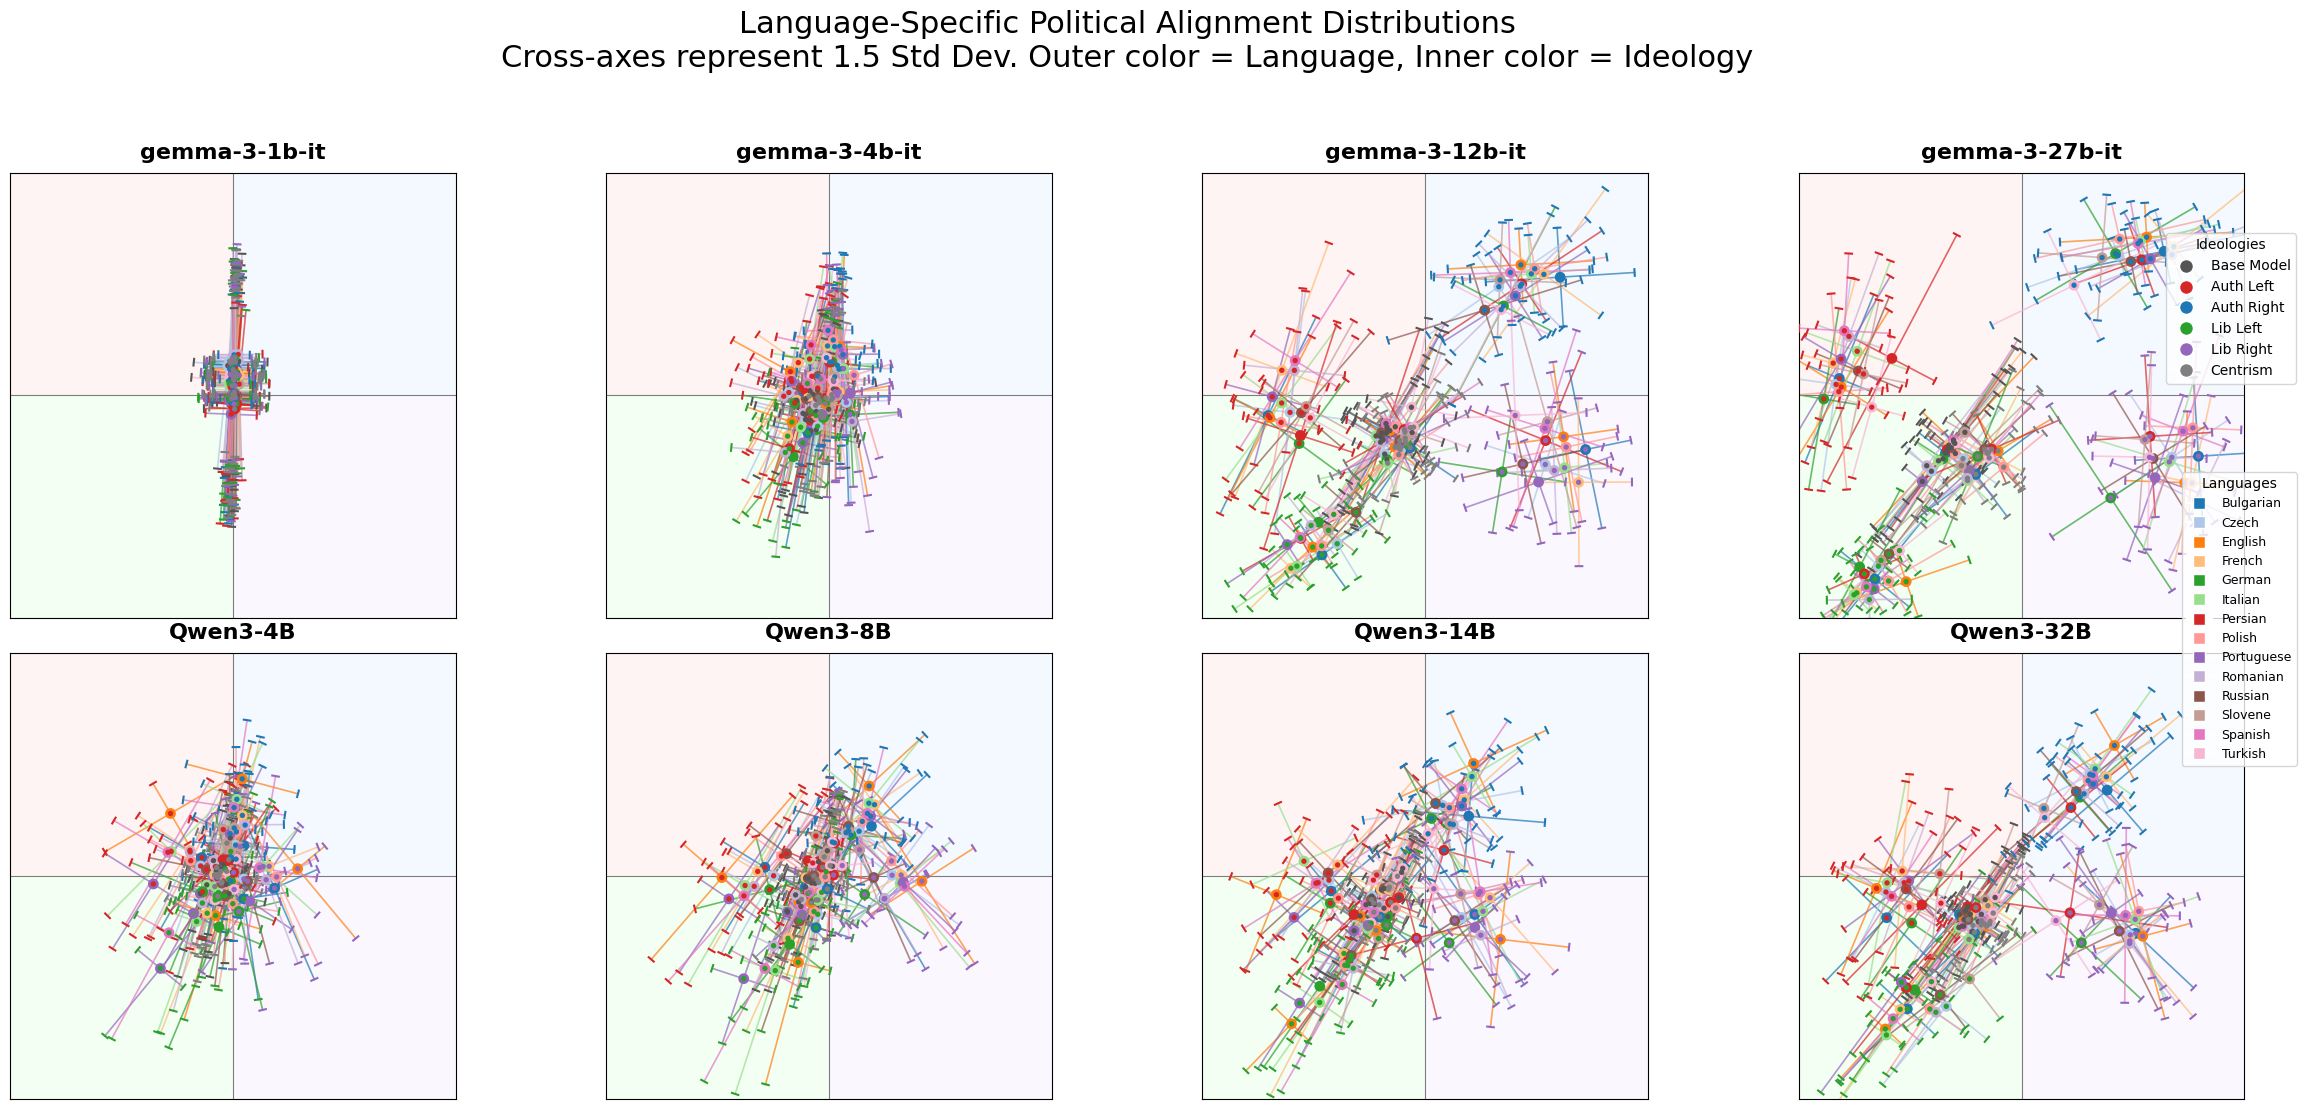

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

# ==========================================
# CONFIGURATION
# ==========================================
RESULTS_DIR = "output/mcq-v1-300/results/"
PARAMS_PATH = "scorer.npz"

FINAL_MODELS = [
    'gemma-3-1b-it', 'gemma-3-4b-it', 'gemma-3-12b-it', 'gemma-3-27b-it',
    'Qwen3-4B', 'Qwen3-8B', 'Qwen3-14B', 'Qwen3-32B'
]

LANGUAGES = [
    "bulgarian", "czech", "english", "french", "german", "italian",
    "persian", "polish", "portuguese", "romanian", "russian",
    "slovene", "spanish", "turkish"
]

DISPLAY_NAMES = {
    "base": "Base Model",
    "authoritarian_left": "Auth Left",
    "authoritarian_right": "Auth Right",
    "libertarian_left": "Lib Left",
    "libertarian_right": "Lib Right",
    "centrism": "Centrism"
}

# Use a qualitative colormap for 14 distinct languages
cmap = plt.get_cmap('tab20')
LANG_COLORS = {lang: cmap(i) for i, lang in enumerate(LANGUAGES)}

IDEOLOGY_COLORS = {
    "Base Model": "#555555",
    "Auth Left":  "#d62728",
    "Auth Right": "#1f77b4",
    "Lib Left":   "#2ca02c",
    "Lib Right":  "#9467bd",
    "Centrism":   "#7f7f7f"
}

# ==========================================
# PLOTTING UTILS
# ==========================================

def draw_distribution_cross(ax, x, y, lang_color, ideo_color, n_std=1.5):
    """Draws the principal component axes of the distribution."""
    if len(x) < 3: return # Need data to calculate covariance
    
    vals = np.vstack([x, y])
    cov = np.cov(vals)
    if np.any(np.isnan(cov)) or np.any(np.isinf(cov)): return
    
    evals, evecs = np.linalg.eigh(cov)
    order = evals.argsort()[::-1]
    evals, evecs = evals[order], evecs[:, order]
    
    mean_x, mean_y = np.mean(x), np.mean(y)
    
    # Draw the two axes (Major and Minor)
    for i in range(2):
        # Length of the arm
        mag = n_std * np.sqrt(evals[i])
        dx, dy = evecs[0, i] * mag, evecs[1, i] * mag
        
        # Main line (Language Color)
        ax.plot([mean_x - dx, mean_x + dx], [mean_y - dy, mean_y + dy], 
                color=lang_color, lw=1.2, alpha=0.7, zorder=2)
        
        # End caps (Ideology Color) - perpendicular to the arm
        cap_size = 0.15
        # Perpendicular vector to (dx, dy) is (-dy, dx)
        pdx, pdy = -evecs[1, i] * cap_size, evecs[0, i] * cap_size
        for side in [-1, 1]:
            ex, ey = mean_x + side*dx, mean_y + side*dy
            ax.plot([ex - pdx, ex + pdx], [ey - pdy, ey + pdy], 
                    color=ideo_color, lw=1.5, zorder=3)

def draw_background(ax):
    ax.set_xlim(-10, 10); ax.set_ylim(-10, 10); ax.set_aspect('equal')
    ax.add_patch(patches.Rectangle((-10, 0), 10, 10, fc='#ff3333', alpha=0.05)) 
    ax.add_patch(patches.Rectangle((0, 0), 10, 10, fc='#3399ff', alpha=0.05))   
    ax.add_patch(patches.Rectangle((-10, -10), 10, 10, fc='#33ff33', alpha=0.05)) 
    ax.add_patch(patches.Rectangle((0, -10), 10, 10, fc='#b366ff', alpha=0.05))   
    ax.axhline(0, color='black', lw=0.8, alpha=0.5); ax.axvline(0, color='black', lw=0.8, alpha=0.5)
    ax.set_xticks([]); ax.set_yticks([])

# ==========================================
# PROCESSING & MAIN PLOT
# ==========================================

def calculate_scores_with_debias(df, W_ECON, W_SOC, B_ECON, B_SOC, NUM_QUESTIONS):
    econ_scores = np.zeros(len(df)) + B_ECON
    soc_scores = np.zeros(len(df)) + B_SOC
    is_reversed = df['perm_id'].isin([2, 3]).values
    
    for q_idx in range(NUM_QUESTIONS):
        cols = [f"q{q_idx}_prob_ans{a}" for a in range(4)]
        if not all(c in df.columns for c in cols): continue
        probs = df[cols].values
        corrected_probs = probs.copy()
        corrected_probs[is_reversed] = probs[is_reversed][:, ::-1]
        econ_scores += np.dot(corrected_probs, W_ECON[q_idx, :])
        soc_scores += np.dot(corrected_probs, W_SOC[q_idx, :])
        
    df['score_econ'] = econ_scores
    df['score_soc'] = soc_scores
    return df

def process_and_plot_language_breakdown():
    # 1. Load Parameters
    try:
        loaded_params = np.load(PARAMS_PATH)
        W_ECON, W_SOC = loaded_params['weights_economic'], loaded_params['weights_social']
        B_ECON, B_SOC = loaded_params['bias_economic'], loaded_params['bias_social']
        NUM_QUESTIONS = W_ECON.shape[0]
    except Exception as e:
        print(f"Error loading parameters: {e}"); return

    # 2. Load and Prepare Data
    all_files = [os.path.join(RESULTS_DIR, f) for f in os.listdir(RESULTS_DIR) if f.endswith(".csv")]
    df_raw = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
    df = df_raw[df_raw['model'].isin(FINAL_MODELS)].copy()
    df = calculate_scores_with_debias(df, W_ECON, W_SOC, B_ECON, B_SOC, NUM_QUESTIONS)
    df['Label'] = df['ideology'].map(DISPLAY_NAMES)

    # 3. Plotting
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))
    axes = axes.flatten()

    for i, model_name in enumerate(FINAL_MODELS):
        ax = axes[i]
        draw_background(ax)
        ax.set_title(model_name, fontsize=16, fontweight='bold', pad=10)
        
        model_df = df[df['model'] == model_name]
        
        # Iterate through Ideologies, then Languages
        for ideo_label, ideo_color in IDEOLOGY_COLORS.items():
            for lang in LANGUAGES:
                subset = model_df[(model_df['Label'] == ideo_label) & (model_df['language'] == lang)]
                
                if subset.empty: continue
                
                x_vals = subset['score_econ'].values
                y_vals = subset['score_soc'].values
                m_x, m_y = x_vals.mean(), y_vals.mean()
                
                lang_color = LANG_COLORS[lang]
                
                # A. Draw the distribution cross (standard deviation axes)
                draw_distribution_cross(ax, x_vals, y_vals, lang_color, ideo_color, n_std=1.5)
                
                # B. Draw Double Marker
                # Outer shell (Language color)
                ax.scatter(m_x, m_y, color=lang_color, s=60, edgecolors='none', zorder=4)
                # Inner core (Ideology color)
                ax.scatter(m_x, m_y, color=ideo_color, s=15, edgecolors='none', zorder=5)

    # Create Legends
    # Ideology Legend
    ideo_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=l) 
                    for l, c in IDEOLOGY_COLORS.items()]
    # Language Legend
    lang_handles = [Line2D([0], [0], marker='s', color='w', markerfacecolor=c, markersize=8, label=l.capitalize()) 
                    for l, c in LANG_COLORS.items()]

    # Place legends on the right or bottom
    first_legend = fig.legend(handles=ideo_handles, title="Ideologies", loc='upper right', 
                               bbox_to_anchor=(0.99, 0.8), frameon=True, fontsize=10)
    fig.legend(handles=lang_handles, title="Languages", loc='upper right', 
               bbox_to_anchor=(0.99, 0.6), frameon=True, fontsize=9, ncol=1)
    
    plt.suptitle("Language-Specific Political Alignment Distributions\nCross-axes represent 1.5 Std Dev. Outer color = Language, Inner color = Ideology", 
                 fontsize=22, y=0.98)
    
    plt.tight_layout(rect=[0, 0.06, 1, 0.94], h_pad=1.5)
    plt.show()

process_and_plot_language_breakdown()

This probably looks to complicated?

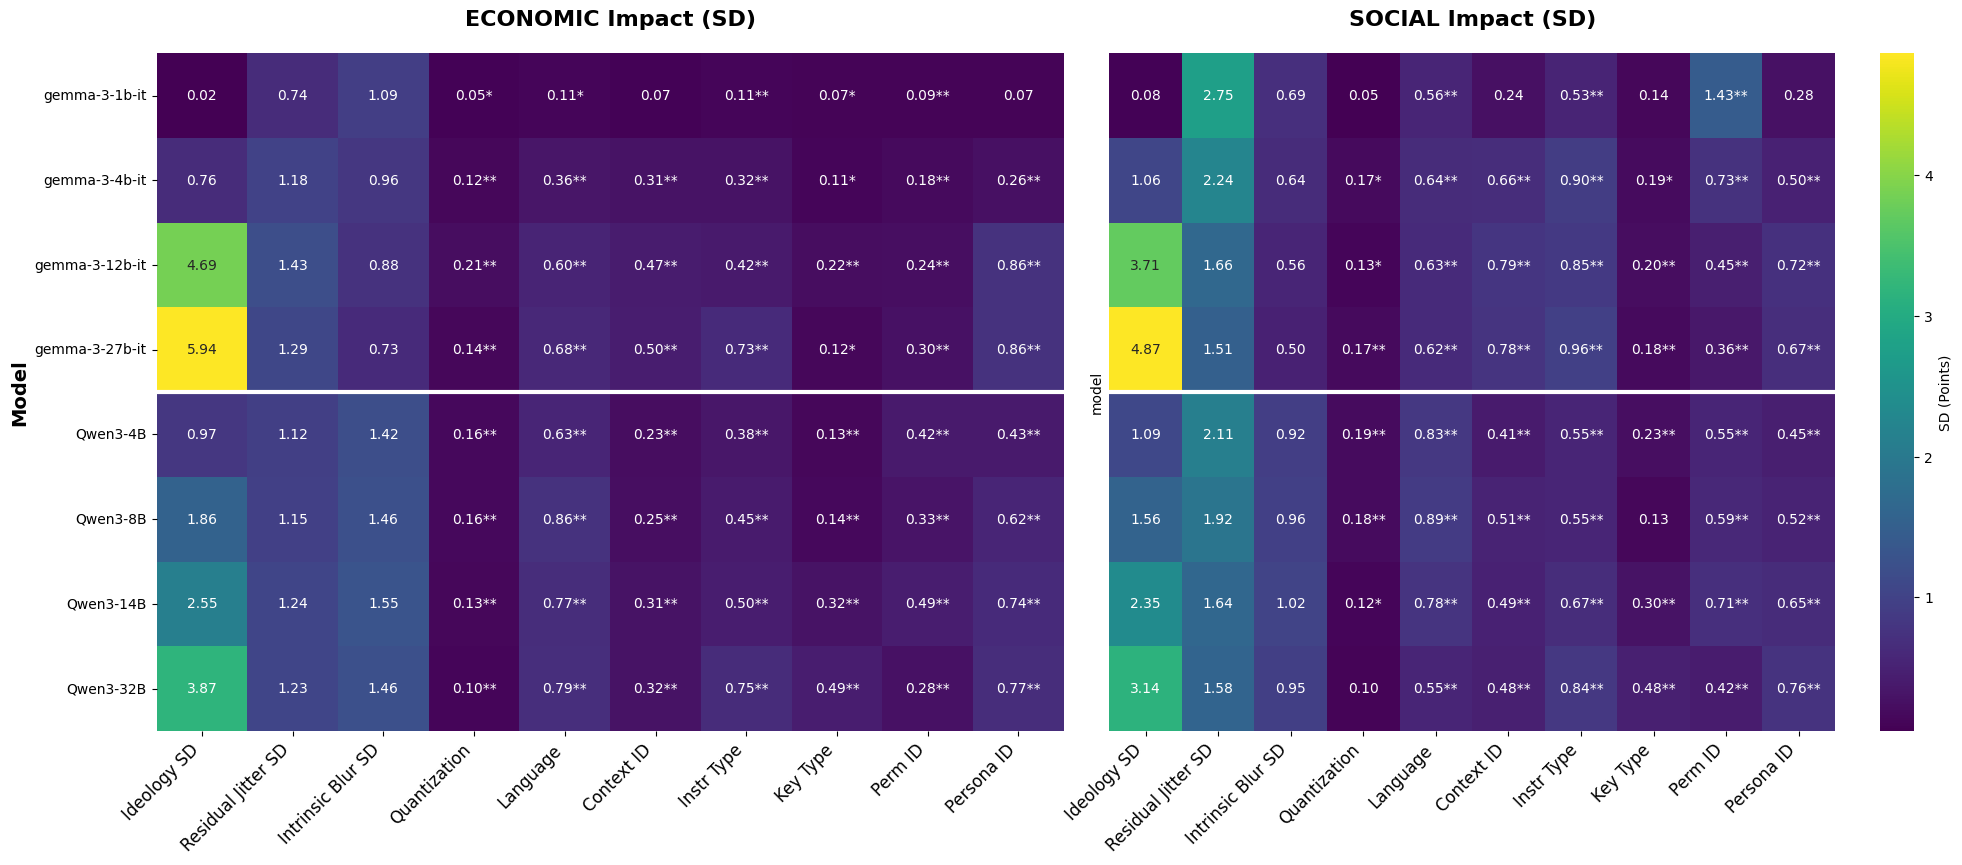

In [3]:


import os
import re
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from scipy.stats import combine_pvalues
from patsy.contrasts import Sum  # Rigor fix for Type III SS

warnings.filterwarnings('ignore')

# ==========================================
# 1. CONFIGURATION & CONSTANTS
# ==========================================
RESULTS_DIR = "output/mcq-v1-300/results/"
PLOTS_OUTPUT_DIR = "./output/mcq-v1-300/plots/"
PARAMS_PATH = "scorer.npz"
os.makedirs(PLOTS_OUTPUT_DIR, exist_ok=True)

FINAL_MODELS = [
    'gemma-3-1b-it', 'gemma-3-4b-it', 'gemma-3-12b-it', 'gemma-3-27b-it',
    'Qwen3-4B', 'Qwen3-8B', 'Qwen3-14B', 'Qwen3-32B',
]

# ==========================================
# 2. CORE UTILITY & FACTOR PREPARATION
# ==========================================

def prepare_rigorous_factors(df):
    """Combines nested QMC factors to accurately partition variance."""
    df = df.copy()
    # Fill NAs for ANOVA
    cols_to_fill = ['quantization', 'language', 'key_type', 'perm_id']
    for c in cols_to_fill:
        if c in df.columns: df[c] = df[c].fillna('None').astype(str)

    # Combine Context (50% None, 5 variants)
    df['context_combo'] = df['context_id'].apply(
        lambda x: 'None' if pd.isna(x) or x == -1 else f"Ctx_{int(x)}"
    )
    # Combine Instruction (2 types, 5 variants)
    df['instr_combo'] = df['instr_type'].astype(str) + "_idx" + df['instr_idx'].fillna(-1).astype(int).astype(str)
    # Combine Persona (2 classes, 5 variants)
    df['persona_combo'] = df.apply(
        lambda row: 'None' if pd.isna(row.get('persona_class')) else f"{row['persona_class']}_idx{int(row['persona_idx'])}", 
        axis=1
    )
    return df

def get_model_sort_key(model_name):
    size_match = re.search(r'(\d+)[BbMm]', model_name)
    size = float(size_match.group(1)) if size_match else 0.0
    family = re.split(r'[-_\d]', model_name)[0].lower()
    return (family, size)

# ==========================================
# 3. SCORING & VARIANCE MATH
# ==========================================

def calculate_intrinsic_variance(df, weights, num_q):
    total_intrinsic_var = np.zeros(len(df))
    is_reversed = df['perm_id'].astype(str).isin(['2', '3']).values
    for q_idx in range(num_q):
        cols = [f"q{q_idx}_prob_ans{a}" for a in range(4)]
        if not all(c in df.columns for c in cols): continue
        probs = df[cols].values
        q_w = weights[q_idx, :]
        row_weights = np.tile(q_w, (len(df), 1))
        row_weights[is_reversed] = q_w[::-1]
        e_w = np.sum(probs * row_weights, axis=1)
        e_w2 = np.sum(probs * (row_weights**2), axis=1)
        total_intrinsic_var += (e_w2 - (e_w**2))
    return total_intrinsic_var

def calculate_scores_with_debias(df, W_ECON, W_SOC, B_ECON, B_SOC, num_q):
    econ_scores = np.zeros(len(df)) + B_ECON
    soc_scores = np.zeros(len(df)) + B_SOC
    is_reversed = df['perm_id'].astype(str).isin(['2', '3']).values
    for q_idx in range(num_q):
        cols = [f"q{q_idx}_prob_ans{a}" for a in range(4)]
        if not all(c in df.columns for c in cols): continue
        probs = df[cols].values
        corrected_probs = probs.copy()
        corrected_probs[is_reversed] = probs[is_reversed][:, ::-1]
        econ_scores += np.dot(corrected_probs, W_ECON[q_idx, :])
        soc_scores += np.dot(corrected_probs, W_SOC[q_idx, :])
    df['score_econ'] = econ_scores
    df['score_soc'] = soc_scores
    return df

# ==========================================
# 4. RIGOROUS ANOVA ANALYSIS (UPDATED)
# ==========================================

def analyze_factor_sensitivity(df, weights, num_q, target_col='score_econ'):
    factors = ['quantization', 'language', 'context_combo', 'instr_combo', 'key_type', 'perm_id', 'persona_combo']
    df['row_intrinsic_var'] = calculate_intrinsic_variance(df, weights, num_q)
    results = []
    
    for model_name, model_df in df.groupby('model'):
        total_n = len(model_df)
        sum_ss_factors = {f: 0.0 for f in factors}
        p_lists = {f: [] for f in factors}
        sum_ss_residual = 0.0
        sum_df_residual = 0.0  # <--- Added tracker for degrees of freedom
        sum_ss_intrinsic = model_df['row_intrinsic_var'].sum()
        sd_ideology = model_df.groupby('ideology')[target_col].mean().std()

        for ideology, sub_df in model_df.groupby('ideology'):
            active_f = [f for f in factors if sub_df[f].nunique() > 1]
            if active_f and len(sub_df) > len(active_f):
                formula = f"{target_col} ~ " + " + ".join([f"C({f}, Sum)" for f in active_f])
                try:
                    model_fit = ols(formula, data=sub_df).fit()
                    tab = anova_lm(model_fit, typ=3)
                    for f in active_f:
                        f_key = f"C({f}, Sum)"
                        sum_ss_factors[f] += tab.loc[f_key, 'sum_sq']
                        p_val = tab.loc[f_key, 'PR(>F)']
                        if not np.isnan(p_val): p_lists[f].append(max(p_val, 1e-15))
                    
                    # Accumulate SS and exact DF from ANOVA
                    sum_ss_residual += tab.loc['Residual', 'sum_sq']
                    sum_df_residual += tab.loc['Residual', 'df']
                except: 
                    # Fallback to sample variance DF (N-1)
                    sum_ss_residual += sub_df[target_col].var() * (len(sub_df) - 1)
                    sum_df_residual += max(len(sub_df) - 1, 0)
            else:
                # No active factors: entire variance is residual
                sum_ss_residual += sub_df[target_col].var() * (max(len(sub_df) - 1, 0))
                sum_df_residual += max(len(sub_df) - 1, 0)

        # Calculate final results using the rigorous DF denominator
        res = {'model': model_name, 'Ideology': sd_ideology, 
               'Residual Jitter': np.sqrt(sum_ss_residual / sum_df_residual) if sum_df_residual > 0 else 0.0,
               'Intrinsic Blur': np.sqrt(sum_ss_intrinsic / total_n)}
        
        for f in factors:
            res[f] = np.sqrt(sum_ss_factors[f] / total_n)
            if p_lists[f]: _, comb_p = combine_pvalues(p_lists[f], method='fisher')
            else: comb_p = 1.0
            res[f + " (p)"] = comb_p
        results.append(res)
        
    return pd.DataFrame(results)

# ==========================================
# 5. HEATMAP PLOTTING
# ==========================================

def plot_sensitivity_heatmap(econ_df, soc_df):
    econ_df['sk'] = econ_df['model'].apply(get_model_sort_key)
    econ_df = econ_df.sort_values('sk').drop('sk', axis=1)
    soc_df = soc_df.set_index('model').reindex(econ_df['model']).reset_index()

    first_cols = ['Ideology', 'Residual Jitter', 'Intrinsic Blur']
    factors = ['quantization', 'language', 'context_combo', 'instr_combo', 'key_type', 'perm_id', 'persona_combo']
    sd_cols = first_cols + factors

    label_map = {
        'Ideology': 'Ideology SD', 'Residual Jitter': 'Residual Jitter SD', 'Intrinsic Blur': 'Intrinsic Blur SD',
        'quantization': 'Quantization', 'language': 'Language', 'context_combo': 'Context ID',
        'instr_combo': 'Instr Type', 'key_type': 'Key Type', 'perm_id': 'Perm ID', 'persona_combo': 'Persona ID'
    }

    def create_annot(df):
        df_idx = df.set_index('model')
        annot = df_idx[sd_cols].copy().astype(str)
        for f in factors:
            for model in df_idx.index:
                p = df_idx.loc[model, f + " (p)"]
                star = "**" if p < 0.00005 else ("*" if p < 0.05 else "")
                annot.loc[model, f] = f"{df_idx.loc[model, f]:.2f}{star}"
        for c in first_cols:
            for model in df_idx.index: annot.loc[model, c] = f"{df_idx.loc[model, c]:.2f}"
        return annot

    fig = plt.figure(figsize=(24, 0.6 * len(econ_df) + 4))
    gs = gridspec.GridSpec(1, 2, wspace=0.05)
    ax1, ax2 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
    
    sns.heatmap(econ_df.set_index('model')[sd_cols], annot=create_annot(econ_df), fmt="", cmap="viridis", ax=ax1, cbar=False)
    sns.heatmap(soc_df.set_index('model')[sd_cols], annot=create_annot(soc_df), fmt="", cmap="viridis", ax=ax2, cbar_kws={'label': 'SD (Points)'})
    
    # Family separators
    families = econ_df['model'].apply(lambda x: x.split('-')[0].split('3')[0]).values
    for i in range(len(families) - 1):
        if families[i] != families[i+1]:
            ax1.axhline(i + 1, color='white', lw=3)
            ax2.axhline(i + 1, color='white', lw=3)

    ax1.set_title("ECONOMIC Impact (SD)", fontsize=16, fontweight='bold', pad=20)
    ax2.set_title("SOCIAL Impact (SD)", fontsize=16, fontweight='bold', pad=20)
    ax2.set_yticks([])

    for ax in [ax1, ax2]:
        new_labels = [label_map.get(l.get_text(), l.get_text()) for l in ax.get_xticklabels()]
        ax.set_xticklabels(new_labels, rotation=45, ha='right', fontsize=12)
        ax.set_xlabel("")
        
    ax1.set_ylabel("Model", fontsize=14, fontweight='bold')
    plt.savefig(os.path.join(PLOTS_OUTPUT_DIR, "factor_sensitivity_rigorous.png"), dpi=150, bbox_inches='tight')
    plt.show()

# ==========================================
# 6. MAIN EXECUTION
# ==========================================

def main():
    params = np.load(PARAMS_PATH)
    W_E, W_S = params['weights_economic'], params['weights_social']
    B_E, B_S = params['bias_economic'], params['bias_social']
    num_q = W_E.shape[0]

    all_files = [os.path.join(RESULTS_DIR, f) for f in os.listdir(RESULTS_DIR) if f.endswith(".csv")]
    if not all_files:
        print("No CSV files found.")
        return
        
    df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
    df = df[df['model'].isin(FINAL_MODELS)].copy()
    
    df = prepare_rigorous_factors(df)
    df = calculate_scores_with_debias(df, W_E, W_S, B_E, B_S, num_q)

    econ_abs = analyze_factor_sensitivity(df, W_E, num_q, 'score_econ')
    soc_abs = analyze_factor_sensitivity(df, W_S, num_q, 'score_soc')
    plot_sensitivity_heatmap(econ_abs, soc_abs)

if __name__ == "__main__":
    main()

In [4]:
import os
import re
import numpy as np
import pandas as pd
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# ==========================================
# 1. CONFIGURATION
# ==========================================
RESULTS_DIR = "output/mcq-v1-300/results/"
PARAMS_PATH = "scorer.npz"
FINAL_MODELS = [
    'gemma-3-1b-it', 'gemma-3-4b-it', 'gemma-3-12b-it', 'gemma-3-27b-it',
    'Qwen3-4B', 'Qwen3-8B', 'Qwen3-14B', 'Qwen3-32B',
]

def prepare_factors(df):
    df = df.copy()
    cols_to_fill = ['quantization', 'language', 'key_type', 'perm_id']
    for c in cols_to_fill:
        if c in df.columns: df[c] = df[c].fillna('None').astype(str)
    df['context_combo'] = df['context_id'].apply(lambda x: 'None' if pd.isna(x) or x == -1 else f"Ctx_{int(x)}")
    df['instr_combo'] = df['instr_type'].astype(str) + "_idx" + df['instr_idx'].fillna(-1).astype(int).astype(str)
    df['persona_combo'] = df.apply(lambda r: 'None' if pd.isna(r.get('persona_class')) else f"{r['persona_class']}_{int(r['persona_idx'])}", axis=1)
    return df

# ==========================================
# 2. CORE CALCULATIONS
# ==========================================

def get_jitter_and_blur(df, weights, bias, target_col, is_temp_0=False):
    """
    Calculates Jitter (ANOVA residual SD) and Blur (Probabilistic SD).
    If is_temp_0 is True, we force probabilities to 1.0 for the max choice.
    """
    df = df.copy()
    num_q = weights.shape[0]
    is_reversed = df['perm_id'].astype(str).isin(['2', '3']).values
    
    # 1. Calculate Scores and Row-wise Intrinsic Variance
    total_scores = np.zeros(len(df)) + bias
    total_intrinsic_var = np.zeros(len(df))

    for q_idx in range(num_q):
        cols = [f"q{q_idx}_prob_ans{a}" for a in range(4)]
        probs = df[cols].values
        
        if is_temp_0:
            # Force probability 1.0 to the most likely answer (Greedy)
            max_idx = np.argmax(probs, axis=1)
            probs = np.zeros_like(probs)
            probs[np.arange(len(probs)), max_idx] = 1.0

        q_w = weights[q_idx, :]
        row_weights = np.tile(q_w, (len(df), 1))
        row_weights[is_reversed] = q_w[::-1]
        
        e_w = np.sum(probs * row_weights, axis=1)
        e_w2 = np.sum(probs * (row_weights**2), axis=1)
        
        total_scores += e_w
        total_intrinsic_var += (e_w2 - (e_w**2))

    df[target_col] = total_scores
    avg_blur_sd = np.sqrt(np.mean(total_intrinsic_var))

    # 2. Calculate Residual Jitter via ANOVA (controlling for factors)
    factors = ['quantization', 'language', 'context_combo', 'instr_combo', 'key_type', 'perm_id', 'persona_combo']
    sum_ss_res = 0.0
    sum_df_res = 0.0

    for _, sub_df in df.groupby('ideology'):
        active_f = [f for f in factors if sub_df[f].nunique() > 1]
        if active_f and len(sub_df) > len(active_f):
            formula = f"{target_col} ~ " + " + ".join([f"C({f})" for f in active_f])
            try:
                model_fit = ols(formula, data=sub_df).fit()
                sum_ss_res += model_fit.ssr
                sum_df_res += model_fit.df_resid
            except:
                sum_ss_res += sub_df[target_col].var() * (len(sub_df)-1)
                sum_df_res += (len(sub_df)-1)
        else:
            sum_ss_res += sub_df[target_col].var() * (len(sub_df)-1)
            sum_df_res += (len(sub_df)-1)

    jitter_sd = np.sqrt(sum_ss_res / sum_df_res) if sum_df_res > 0 else 0
    return jitter_sd, avg_blur_sd

# ==========================================
# 3. EXECUTION & TABLE FORMATTING
# ==========================================

def main():
    if not os.path.exists(PARAMS_PATH):
        print(f"Error: {PARAMS_PATH} not found.")
        return

    params = np.load(PARAMS_PATH)
    all_files = [os.path.join(RESULTS_DIR, f) for f in os.listdir(RESULTS_DIR) if f.endswith(".csv")]
    raw_df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
    raw_df = raw_df[raw_df['model'].isin(FINAL_MODELS)].copy()
    raw_df = prepare_factors(raw_df)

    results = []

    for m_name in FINAL_MODELS:
        m_df = raw_df[raw_df['model'] == m_name]
        if m_df.empty: continue
        
        # Economic
        j_e_orig, b_e_orig = get_jitter_and_blur(m_df, params['weights_economic'], params['bias_economic'], 'sc_e', False)
        j_e_t0, b_e_t0 = get_jitter_and_blur(m_df, params['weights_economic'], params['bias_economic'], 'sc_e', True)
        
        # Social
        j_s_orig, b_s_orig = get_jitter_and_blur(m_df, params['weights_social'], params['bias_social'], 'sc_s', False)
        j_s_t0, b_s_t0 = get_jitter_and_blur(m_df, params['weights_social'], params['bias_social'], 'sc_s', True)

        results.append({
            'Model': m_name,
            'Econ (Orig)': np.sqrt(j_e_orig**2 + b_e_orig**2),
            'Econ (T=0)': np.sqrt(j_e_t0**2 + 0), # Blur is 0 at T=0
            'Soc (Orig)': np.sqrt(j_s_orig**2 + b_s_orig**2),
            'Soc (T=0)': np.sqrt(j_s_t0**2 + 0)
        })

    res_df = pd.DataFrame(results).set_index('Model').T
    
    print("\nCOMBINED UNCERTAINTY SCORE: sqrt(Jitter^2 + Intrinsic_Blur^2)")
    print("Columns: Models | Rows: Measurement Type & Temperature Setting")
    print("-" * 100)
    print(res_df.round(3).to_string())
    print("-" * 100)

if __name__ == "__main__":
    main()


COMBINED UNCERTAINTY SCORE: sqrt(Jitter^2 + Intrinsic_Blur^2)
Columns: Models | Rows: Measurement Type & Temperature Setting
----------------------------------------------------------------------------------------------------
Model        gemma-3-1b-it  gemma-3-4b-it  gemma-3-12b-it  gemma-3-27b-it  Qwen3-4B  Qwen3-8B  Qwen3-14B  Qwen3-32B
Econ (Orig)          1.313          1.527           1.675           1.483     1.808     1.858      1.985      1.909
Econ (T=0)           1.115          1.447           1.637           1.461     1.692     1.844      1.996      1.930
Soc (Orig)           2.838          2.326           1.752           1.593     2.305     2.147      1.932      1.844
Soc (T=0)            3.023          2.463           1.809           1.659     2.824     2.761      2.507      2.325
----------------------------------------------------------------------------------------------------


Processing T=0.0...
Processing T=0.1...
Processing T=0.2...
Processing T=0.3...
Processing T=0.4...
Processing T=0.5...
Processing T=0.6...
Processing T=0.7...
Processing T=0.8...
Processing T=0.9...
Processing T=1.0...
Processing T=1.1...
Processing T=1.2...
Processing T=1.3...
Processing T=1.4...
Processing T=1.5...
Processing T=1.6...
Processing T=1.7...
Processing T=1.8...
Processing T=1.9...
Processing T=2.0...


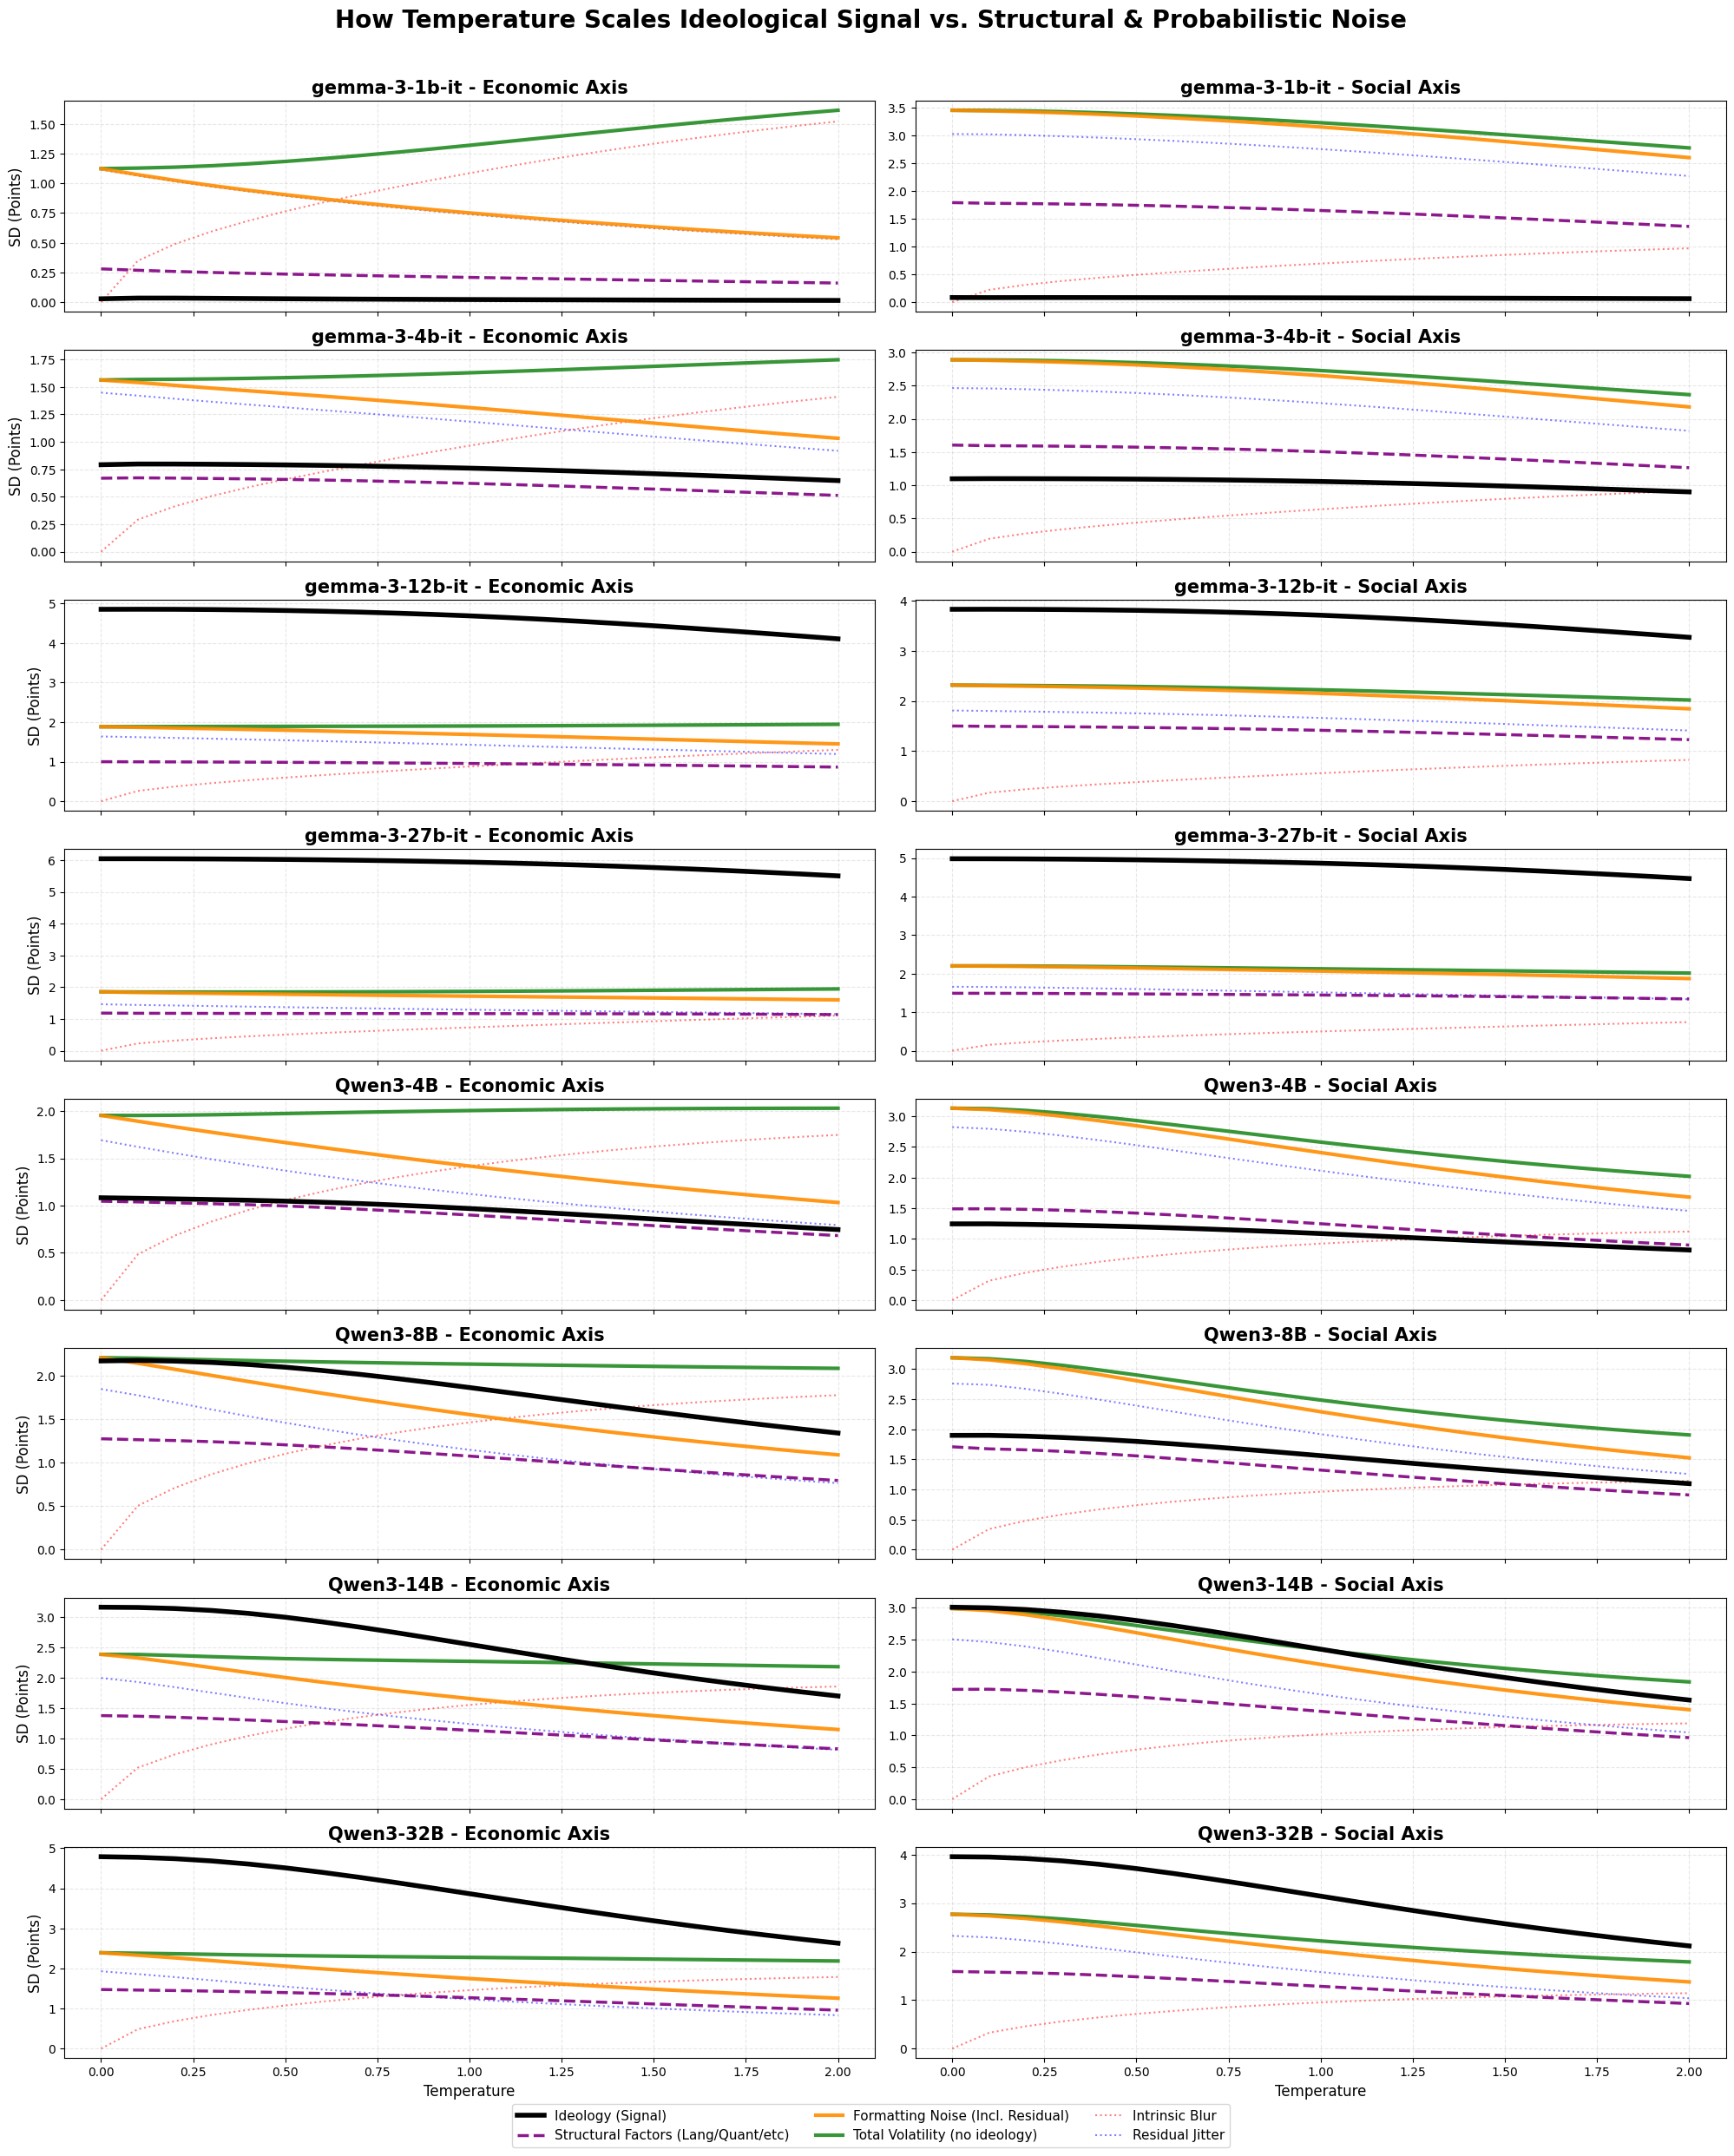

In [5]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from scipy.stats import combine_pvalues
from patsy.contrasts import Sum

warnings.filterwarnings('ignore')

# ==========================================
# 1. CONFIGURATION & CONSTANTS
# ==========================================
RESULTS_DIR = "output/mcq-v1-300/results/"
PLOTS_OUTPUT_DIR = "output/mcq-v1-300/plots/"
PARAMS_PATH = "scorer.npz"
os.makedirs(PLOTS_OUTPUT_DIR, exist_ok=True)

TARGET_MODELS = [    
    'gemma-3-1b-it', 'gemma-3-4b-it', 'gemma-3-12b-it', 'gemma-3-27b-it',
    'Qwen3-4B', 'Qwen3-8B', 'Qwen3-14B', 'Qwen3-32B',
]

# TARGET_MODELS = [    
#     'gemma-3-27b-it',  'Qwen3-32B',
# ]

TEMPERATURES = np.linspace(0.0, 2.0, 21)

# ==========================================
# 2. CORE UTILITY & FACTOR PREPARATION
# ==========================================

def prepare_rigorous_factors(df):
    df = df.copy()
    cols_to_fill = ['quantization', 'language', 'key_type', 'perm_id']
    for c in cols_to_fill:
        if c in df.columns: df[c] = df[c].fillna('None').astype(str)

    df['context_combo'] = df['context_id'].apply(
        lambda x: 'None' if pd.isna(x) or x == -1 else f"Ctx_{int(x)}"
    )
    df['instr_combo'] = df['instr_type'].astype(str) + "_idx" + df['instr_idx'].fillna(-1).astype(int).astype(str)
    df['persona_combo'] = df.apply(
        lambda row: 'None' if pd.isna(row.get('persona_class')) else f"{row['persona_class']}_idx{int(row['persona_idx'])}", 
        axis=1
    )
    return df

def apply_temperature(df, num_q, temp=1.0):
    if temp == 1.0: return df.copy()
    df_temp = df.copy()
    for q_idx in range(num_q):
        cols = [f"q{q_idx}_prob_ans{a}" for a in range(4)]
        if not all(c in df_temp.columns for c in cols): continue
        probs = df_temp[cols].values.astype(float)
        nan_mask = np.isnan(probs).any(axis=1)
        safe_probs = np.nan_to_num(probs, nan=0.0)
        if temp == 0.0:
            max_idx = np.argmax(safe_probs, axis=1)
            new_probs = np.zeros_like(probs)
            new_probs[np.arange(len(probs)), max_idx] = 1.0
            new_probs[nan_mask] = np.nan
            df_temp[cols] = new_probs
        else:
            eps = 1e-12
            logits = np.log(np.clip(safe_probs, eps, 1.0))
            scaled_logits = logits / temp
            exp_logits = np.exp(scaled_logits - np.max(scaled_logits, axis=1, keepdims=True))
            new_probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
            new_probs[nan_mask] = np.nan
            df_temp[cols] = new_probs
    return df_temp

def calculate_intrinsic_variance(df, weights, num_q):
    total_intrinsic_var = np.zeros(len(df))
    is_reversed = df['perm_id'].astype(str).isin(['2', '3']).values
    for q_idx in range(num_q):
        cols = [f"q{q_idx}_prob_ans{a}" for a in range(4)]
        if not all(c in df.columns for c in cols): continue
        probs = df[cols].values
        q_w = weights[q_idx, :]
        row_weights = np.tile(q_w, (len(df), 1))
        row_weights[is_reversed] = q_w[::-1]
        e_w = np.sum(probs * row_weights, axis=1)
        e_w2 = np.sum(probs * (row_weights**2), axis=1)
        total_intrinsic_var += (e_w2 - (e_w**2))
    return total_intrinsic_var

def calculate_scores_with_debias(df, W_ECON, W_SOC, B_ECON, B_SOC, num_q):
    econ_scores = np.zeros(len(df)) + B_ECON
    soc_scores = np.zeros(len(df)) + B_SOC
    is_reversed = df['perm_id'].astype(str).isin(['2', '3']).values
    for q_idx in range(num_q):
        cols = [f"q{q_idx}_prob_ans{a}" for a in range(4)]
        if not all(c in df.columns for c in cols): continue
        probs = df[cols].values
        corrected_probs = probs.copy()
        corrected_probs[is_reversed] = probs[is_reversed][:, ::-1]
        econ_scores += np.dot(corrected_probs, W_ECON[q_idx, :])
        soc_scores += np.dot(corrected_probs, W_SOC[q_idx, :])
    df['score_econ'] = econ_scores
    df['score_soc'] = soc_scores
    return df

# ==========================================
# 3. ANALYSIS & VARIANCE AGGREGATION
# ==========================================

def analyze_factor_sensitivity(df, weights, num_q, target_col='score_econ'):
    factors = ['quantization', 'language', 'context_combo', 'instr_combo', 'key_type', 'perm_id', 'persona_combo']
    df['row_intrinsic_var'] = calculate_intrinsic_variance(df, weights, num_q)
    results = []
    
    for model_name, model_df in df.groupby('model'):
        total_n = len(model_df)
        sum_ss_factors = {f: 0.0 for f in factors}
        sum_ss_residual = 0.0
        sum_df_residual = 0.0  
        sum_ss_intrinsic = model_df['row_intrinsic_var'].sum()
        sd_ideology = model_df.groupby('ideology')[target_col].mean().std()

        for ideology, sub_df in model_df.groupby('ideology'):
            active_f = [f for f in factors if sub_df[f].nunique() > 1]
            if active_f and len(sub_df) > len(active_f):
                formula = f"{target_col} ~ " + " + ".join([f"C({f}, Sum)" for f in active_f])
                try:
                    model_fit = ols(formula, data=sub_df).fit()
                    tab = anova_lm(model_fit, typ=3)
                    for f in active_f: sum_ss_factors[f] += tab.loc[f"C({f}, Sum)", 'sum_sq']
                    sum_ss_residual += tab.loc['Residual', 'sum_sq']
                    sum_df_residual += tab.loc['Residual', 'df']
                except: 
                    sum_ss_residual += sub_df[target_col].var() * (len(sub_df) - 1)
                    sum_df_residual += max(len(sub_df) - 1, 0)
            else:
                sum_ss_residual += sub_df[target_col].var() * (max(len(sub_df) - 1, 0))
                sum_df_residual += max(len(sub_df) - 1, 0)

        # Basic SDs
        res = {'model': model_name, 'Ideology': sd_ideology, 
               'Residual Jitter': np.sqrt(sum_ss_residual / sum_df_residual) if sum_df_residual > 0 else 0.0,
               'Intrinsic Blur': np.sqrt(sum_ss_intrinsic / total_n)}
        for f in factors:
            res[f] = np.sqrt(sum_ss_factors[f] / total_n)
        
        # --- AGGREGATE CALCULATIONS (Combined Variances) ---
        nuisance_vars = ['quantization', 'language', 'context_combo', 'instr_combo', 'key_type', 'perm_id']
        
        # NEW: Combined SD of structural factors only (Nuisance factors excluding residual/blur/persona)
        res['Structural_Factors_SD'] = np.sqrt(sum(sum_ss_factors[f] for f in nuisance_vars) / total_n)
        
        # 1. Combined SD for all factors apart from Persona and Intrinsic Blur
        ss_nuisance = sum(sum_ss_factors[f] for f in nuisance_vars) + sum_ss_residual
        res['Combined_Noise_NoBlur_NoPersona'] = np.sqrt(ss_nuisance / total_n)
        
        # 2. Combined SD for all factors apart from Persona (Adds Intrinsic Blur)
        ss_volatility = ss_nuisance + sum_ss_intrinsic
        res['Combined_Volatility_NoPersona'] = np.sqrt(ss_volatility / total_n)

        results.append(res)
    return pd.DataFrame(results)

# ==========================================
# 4. PLOTTING
# ==========================================

def plot_temperature_dynamics(results_df):
    fig, axes = plt.subplots(len(TARGET_MODELS), 2, figsize=(20, 24), sharex=True)
    
    for i, model in enumerate(TARGET_MODELS):
        for j, dim in enumerate(['Economic', 'Social']):
            ax = axes[i, j]
            sub_df = results_df[(results_df['model'] == model) & (results_df['Dimension'] == dim)].sort_values('Temperature')
            
            # --- Primary Signal ---
            ax.plot(sub_df['Temperature'], sub_df['Ideology'], 
                    label='Ideology (Signal)', color='black', linewidth=4, zorder=10)
            
            # --- THE AGGREGATE LINES ---
            # NEW: Structural Factors SD (The combined "Main Factors" like Lang/Quant/Context)
            ax.plot(sub_df['Temperature'], sub_df['Structural_Factors_SD'], 
                    label='Structural Factors (Lang/Quant/etc)', color='purple', linewidth=2.5, linestyle='--', alpha=0.9, zorder=9)

            # Combined Noise (Technical/Formatting only)
            ax.plot(sub_df['Temperature'], sub_df['Combined_Noise_NoBlur_NoPersona'], 
                    label='Formatting Noise (Incl. Residual)', color='darkorange', linewidth=3, linestyle='-', alpha=0.9, zorder=8)
            
            # Combined Volatility (Technical + Probabilistic)
            ax.plot(sub_df['Temperature'], sub_df['Combined_Volatility_NoPersona'], 
                    label='Total Volatility (no ideology)', color='forestgreen', linewidth=3, linestyle='-', alpha=0.9, zorder=7)

            # --- Individual Components (Lighter lines for context) ---
            ax.plot(sub_df['Temperature'], sub_df['Intrinsic Blur'], label='Intrinsic Blur', color='red', linestyle=':', alpha=0.5)
            ax.plot(sub_df['Temperature'], sub_df['Residual Jitter'], label='Residual Jitter', color='blue', linestyle=':', alpha=0.5)
            
            ax.set_title(f"{model} - {dim} Axis", fontsize=15, fontweight='bold')
            ax.grid(True, linestyle='--', alpha=0.3)
            
            if i == len(TARGET_MODELS) - 1:
                ax.set_xlabel("Temperature", fontsize=12)
            if j == 0:
                ax.set_ylabel("SD (Points)", fontsize=12)

    handles, labels = axes[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02), fontsize=11)
    plt.suptitle("How Temperature Scales Ideological Signal vs. Structural & Probabilistic Noise", fontsize=20, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_OUTPUT_DIR, "temperature_performance_scaling.png"), dpi=150, bbox_inches='tight')
    plt.show()

# ==========================================
# 5. MAIN
# ==========================================

def main():
    params = np.load(PARAMS_PATH)
    W_E, W_S, B_E, B_S = params['weights_economic'], params['weights_social'], params['bias_economic'], params['bias_social']
    num_q = W_E.shape[0]

    all_files = [os.path.join(RESULTS_DIR, f) for f in os.listdir(RESULTS_DIR) if f.endswith(".csv")]
    df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
    pristine_df = prepare_rigorous_factors(df[df['model'].isin(TARGET_MODELS)])
    
    all_results = []
    for temp in TEMPERATURES:
        print(f"Processing T={temp:.1f}...")
        temp_df = apply_temperature(pristine_df, num_q, temp=temp)
        temp_df = calculate_scores_with_debias(temp_df, W_E, W_S, B_E, B_S, num_q)
        
        for dim, w, col in [('Economic', W_E, 'score_econ'), ('Social', W_S, 'score_soc')]:
            res = analyze_factor_sensitivity(temp_df, w, num_q, col)
            res['Temperature'] = temp
            res['Dimension'] = dim
            all_results.append(res)

    plot_temperature_dynamics(pd.concat(all_results))

if __name__ == "__main__":
    main()

Processing T=0.0...
Processing T=0.1...
Processing T=0.2...
Processing T=0.3...
Processing T=0.4...
Processing T=0.5...
Processing T=0.6...
Processing T=0.7...
Processing T=0.8...
Processing T=0.9...
Processing T=1.0...
Processing T=1.1...
Processing T=1.2...
Processing T=1.3...
Processing T=1.4...
Processing T=1.5...
Processing T=1.6...
Processing T=1.7...
Processing T=1.8...
Processing T=1.9...
Processing T=2.0...


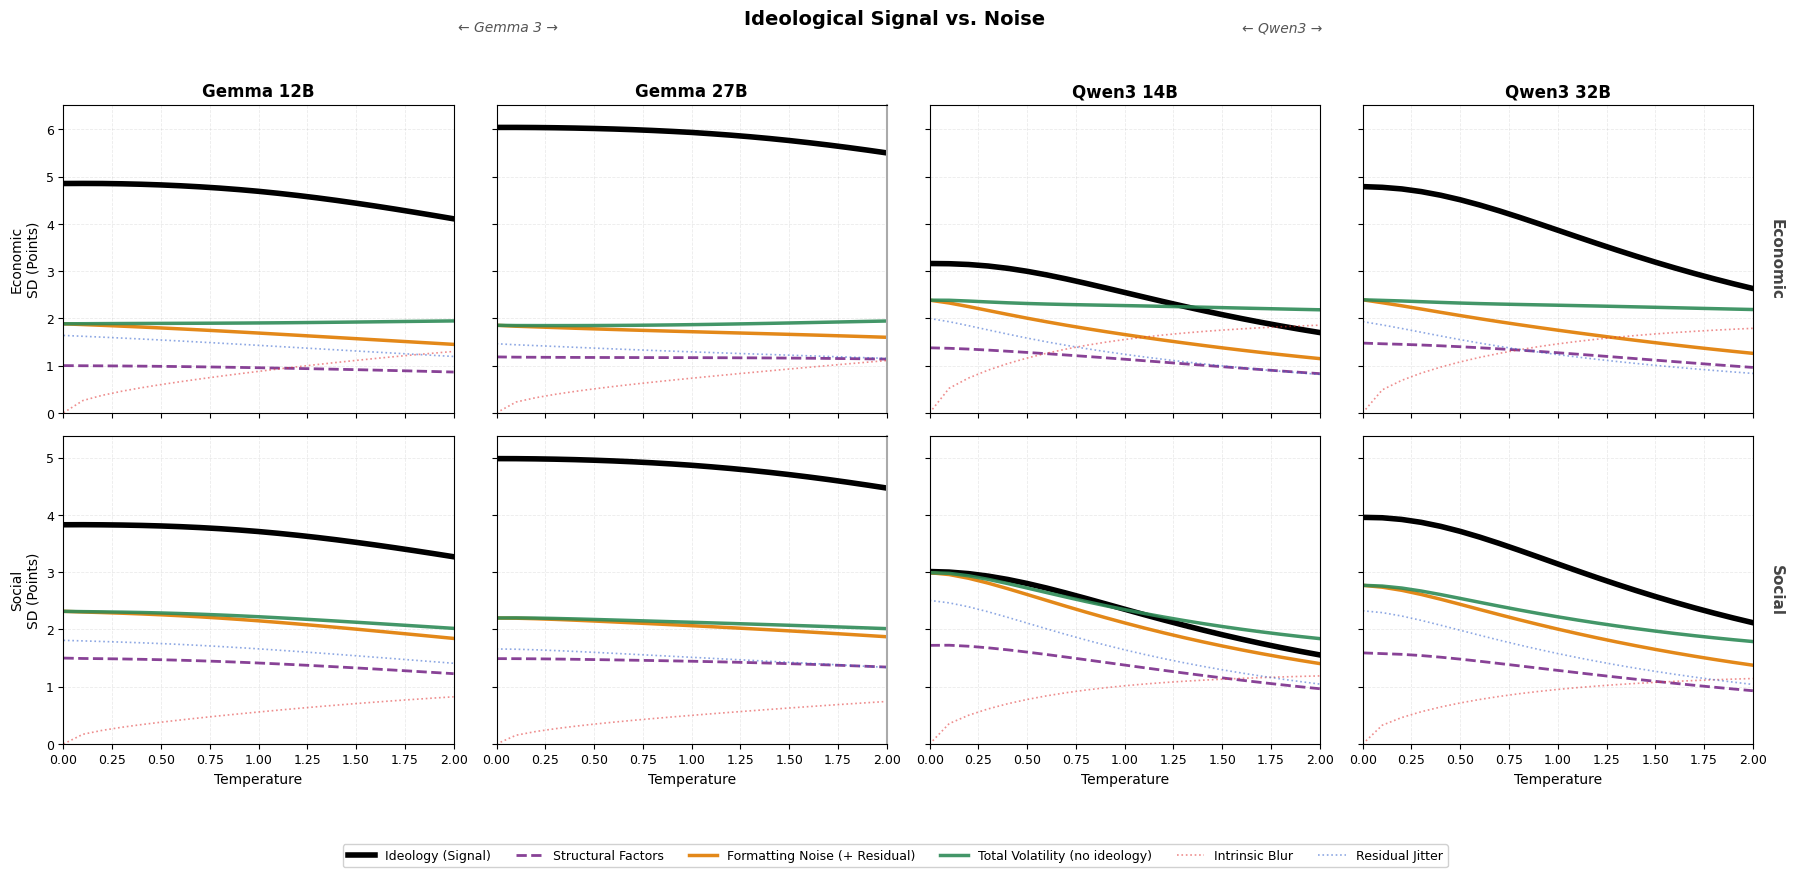

In [6]:
# ==========================================
# FOCUSED PLOT: 2×4 Fixed-Axis Figure
# ==========================================

FOCAL_MODELS = [
    'gemma-3-12b-it', 'gemma-3-27b-it',
    'Qwen3-14B',       'Qwen3-32B',
]

MODEL_LABELS = {
    'gemma-3-12b-it': 'Gemma 12B',
    'gemma-3-27b-it': 'Gemma 27B',
    'Qwen3-14B':      'Qwen3 14B',
    'Qwen3-32B':      'Qwen3 32B',
}

# Color palette — tweak to taste
PALETTE = {
    'Ideology (Signal)':               ('black',       4.0, '-',  1.0),
    'Structural Factors':              ('#7b2d8b',     2.0, '--', 0.9),  # purple
    'Formatting Noise (+ Residual)':   ('#E07B00',     2.5, '-',  0.9),  # orange
    'Total Volatility (no ideology)':  ('#2e8b57',     2.5, '-',  0.9),  # green
    'Intrinsic Blur':                  ('#e03030',     1.2, ':',  0.55), # red
    'Residual Jitter':                 ('#3060cc',     1.2, ':',  0.55), # blue
}

def plot_focused(results_df):
    fig, axes = plt.subplots(
        2, 4,
        figsize=(18, 8),
        sharex=True,
        sharey='row',   # fix y per row (Economic / Social)
    )

    # --- Compute shared y-limits per dimension ---
    y_lims = {}
    for dim in ['Economic', 'Social']:
        dim_df = results_df[
            (results_df['model'].isin(FOCAL_MODELS)) &
            (results_df['Dimension'] == dim)
        ]
        # Include all plotted series in the range calculation
        series_cols = [
            'Ideology', 'Structural_Factors_SD',
            'Combined_Noise_NoBlur_NoPersona',
            'Combined_Volatility_NoPersona',
            'Intrinsic Blur', 'Residual Jitter'
        ]
        ymin = dim_df[series_cols].min().min()
        ymax = dim_df[series_cols].max().max()
        pad  = (ymax - ymin) * 0.08
        y_lims[dim] = (max(0, ymin - pad), ymax + pad)

    dims = ['Economic', 'Social']
    for row_i, dim in enumerate(dims):
        for col_i, model in enumerate(FOCAL_MODELS):
            ax = axes[row_i, col_i]
            sub = (
                results_df[
                    (results_df['model'] == model) &
                    (results_df['Dimension'] == dim)
                ]
                .sort_values('Temperature')
            )

            # --- Plot each series ---
            series_map = {
                'Ideology (Signal)':             'Ideology',
                'Structural Factors':            'Structural_Factors_SD',
                'Formatting Noise (+ Residual)': 'Combined_Noise_NoBlur_NoPersona',
                'Total Volatility (no ideology)':'Combined_Volatility_NoPersona',
                'Intrinsic Blur':                'Intrinsic Blur',
                'Residual Jitter':               'Residual Jitter',
            }
            for label, col in series_map.items():
                color, lw, ls, alpha = PALETTE[label]
                ax.plot(
                    sub['Temperature'], sub[col],
                    color=color, linewidth=lw, linestyle=ls,
                    alpha=alpha, label=label
                )

            # --- Titles & axes ---
            ax.set_ylim(*y_lims[dim])
            ax.set_xlim(0.0, 2.0)
            ax.grid(True, linestyle='--', alpha=0.25, linewidth=0.6)
            ax.tick_params(labelsize=9)

            if row_i == 0:
                # Model name on top, family label as subtitle
                family = 'Gemma 3' if 'gemma' in model else 'Qwen3'
                ax.set_title(
                    f"{MODEL_LABELS[model]}",
                    fontsize=12, fontweight='bold', pad=6
                )
            if row_i == 1:
                ax.set_xlabel("Temperature", fontsize=10)
            if col_i == 0:
                ax.set_ylabel(f"{dim}\nSD (Points)", fontsize=10)

            # Subtle family separator — faint vertical divider between col 1 and 2
            if col_i == 1:
                ax.spines['right'].set_linewidth(1.5)
                ax.spines['right'].set_color('#aaaaaa')

    # --- Row labels on the right ---
    for row_i, dim in enumerate(dims):
        axes[row_i, -1].annotate(
            dim, xy=(1.04, 0.5), xycoords='axes fraction',
            fontsize=11, fontweight='bold', va='center', rotation=270,
            color='#444444'
        )

    # --- Family brackets above top row ---
    fig.text(0.285, 1.002, '← Gemma 3 →',
             ha='center', fontsize=10, color='#555', style='italic')
    fig.text(0.715, 1.002, '← Qwen3 →',
             ha='center', fontsize=10, color='#555', style='italic')

    # --- Shared legend at the bottom ---
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
    handles, labels,
    loc='lower center', ncol=6,
    bbox_to_anchor=(0.5, -0.05),
    fontsize=9, framealpha=0.9,
    handlelength=2.2
    )



    fig.suptitle(
        "Ideological Signal vs. Noise",
        fontsize=14, fontweight='bold', y=1.03
    )

    
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig(
        os.path.join(PLOTS_OUTPUT_DIR, "temperature.png"),
        dpi=180, bbox_inches='tight'
    )
    plt.show()

# def main():
params = np.load(PARAMS_PATH)
W_E, W_S, B_E, B_S = params['weights_economic'], params['weights_social'], params['bias_economic'], params['bias_social']
num_q = W_E.shape[0]

all_files = [os.path.join(RESULTS_DIR, f) for f in os.listdir(RESULTS_DIR) if f.endswith(".csv")]
df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
pristine_df = prepare_rigorous_factors(df[df['model'].isin(TARGET_MODELS)])

all_results = []
for temp in TEMPERATURES:
    print(f"Processing T={temp:.1f}...")
    temp_df = apply_temperature(pristine_df, num_q, temp=temp)
    temp_df = calculate_scores_with_debias(temp_df, W_E, W_S, B_E, B_S, num_q)
    
    for dim, w, col in [('Economic', W_E, 'score_econ'), ('Social', W_S, 'score_soc')]:
        res = analyze_factor_sensitivity(temp_df, w, num_q, col)
        res['Temperature'] = temp
        res['Dimension'] = dim
        all_results.append(res)

final_df = pd.concat(all_results)
# plot_temperature_dynamics(final_df)  # keep for appendix (maybe)
plot_focused(final_df)

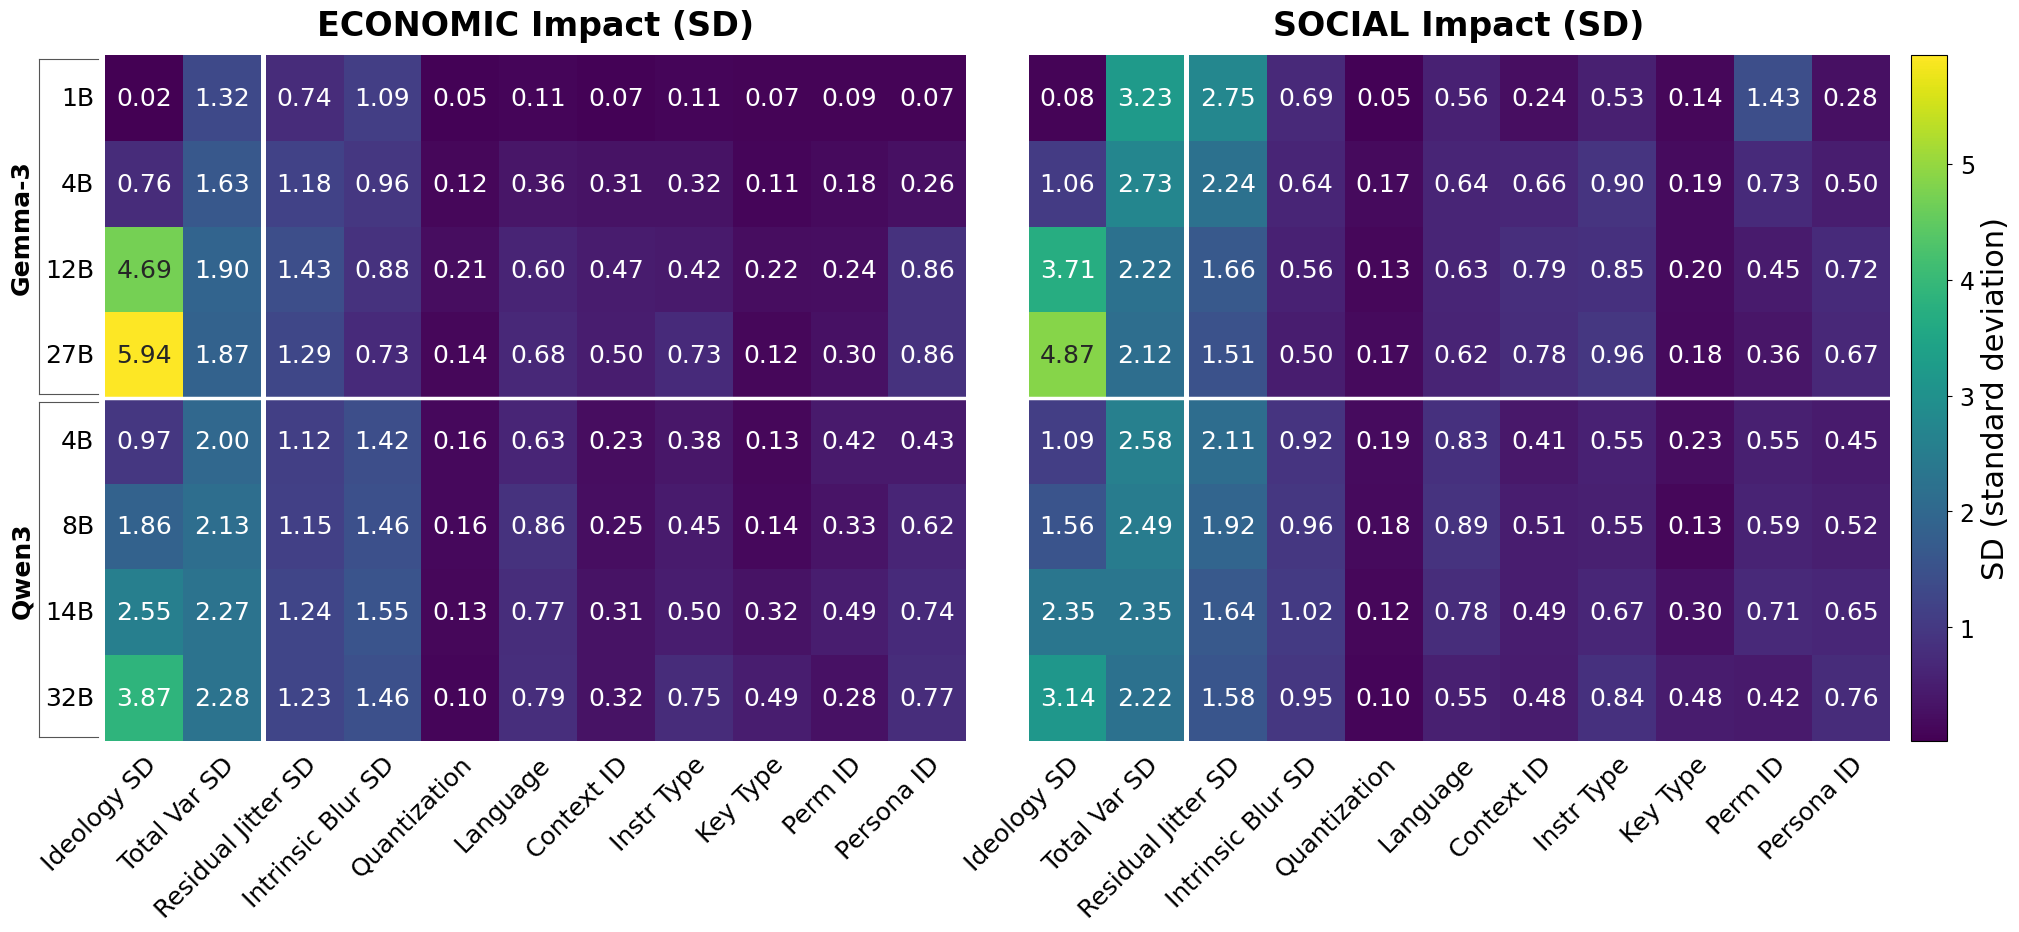

In [7]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from scipy.stats import combine_pvalues
from patsy.contrasts import Sum

warnings.filterwarnings('ignore')

# ==========================================
# 1. CONFIGURATION & CONSTANTS
# ==========================================
RESULTS_DIR = "output/mcq-v1-300/results/"
PLOTS_OUTPUT_DIR = "output/mcq-v1-300/plots/"
PARAMS_PATH = "scorer.npz"
os.makedirs(PLOTS_OUTPUT_DIR, exist_ok=True)

FINAL_MODELS = [
    'gemma-3-1b-it', 'gemma-3-4b-it', 'gemma-3-12b-it', 'gemma-3-27b-it',
    'Qwen3-4B', 'Qwen3-8B', 'Qwen3-14B', 'Qwen3-32B',
]

# ==========================================
# 2. CORE UTILITY & FACTOR PREPARATION
# ==========================================

def prepare_rigorous_factors(df):
    df = df.copy()
    cols_to_fill = ['quantization', 'language', 'key_type', 'perm_id']
    for c in cols_to_fill:
        if c in df.columns:
            df[c] = df[c].fillna('None').astype(str)
    df['context_combo'] = df['context_id'].apply(
        lambda x: 'None' if pd.isna(x) or x == -1 else f"Ctx_{int(x)}"
    )
    df['instr_combo'] = (df['instr_type'].astype(str) + "_idx"
                         + df['instr_idx'].fillna(-1).astype(int).astype(str))
    df['persona_combo'] = df.apply(
        lambda row: 'None' if pd.isna(row.get('persona_class'))
                    else f"{row['persona_class']}_idx{int(row['persona_idx'])}",
        axis=1
    )
    return df


def get_model_sort_key(model_name):
    size_match = re.search(r'(\d+)[BbMm]', model_name)
    size = float(size_match.group(1)) if size_match else 0.0
    family = re.split(r'[-_\d]', model_name)[0].lower()
    return (family, size)


# ==========================================
# 3. SCORING & VARIANCE MATH
# ==========================================

def calculate_intrinsic_variance(df, weights, num_q):
    total_intrinsic_var = np.zeros(len(df))
    is_reversed = df['perm_id'].astype(str).isin(['2', '3']).values
    for q_idx in range(num_q):
        cols = [f"q{q_idx}_prob_ans{a}" for a in range(4)]
        if not all(c in df.columns for c in cols):
            continue
        probs = df[cols].values
        q_w = weights[q_idx, :]
        row_weights = np.tile(q_w, (len(df), 1))
        row_weights[is_reversed] = q_w[::-1]
        e_w  = np.sum(probs * row_weights, axis=1)
        e_w2 = np.sum(probs * (row_weights ** 2), axis=1)
        total_intrinsic_var += (e_w2 - e_w ** 2)
    return total_intrinsic_var


def calculate_scores_with_debias(df, W_ECON, W_SOC, B_ECON, B_SOC, num_q):
    econ_scores = np.zeros(len(df)) + B_ECON
    soc_scores  = np.zeros(len(df)) + B_SOC
    is_reversed = df['perm_id'].astype(str).isin(['2', '3']).values
    for q_idx in range(num_q):
        cols = [f"q{q_idx}_prob_ans{a}" for a in range(4)]
        if not all(c in df.columns for c in cols):
            continue
        probs = df[cols].values
        corrected = probs.copy()
        corrected[is_reversed] = probs[is_reversed][:, ::-1]
        econ_scores += np.dot(corrected, W_ECON[q_idx, :])
        soc_scores  += np.dot(corrected, W_SOC[q_idx, :])
    df['score_econ'] = econ_scores
    df['score_soc']  = soc_scores
    return df


# ==========================================
# 4. ANOVA ANALYSIS
# ==========================================

def analyze_factor_sensitivity(df, weights, num_q, target_col='score_econ'):
    factors = ['quantization', 'language', 'context_combo', 'instr_combo',
               'key_type', 'perm_id', 'persona_combo']
    df['row_intrinsic_var'] = calculate_intrinsic_variance(df, weights, num_q)
    results = []

    for model_name, model_df in df.groupby('model'):
        total_n = len(model_df)
        sum_ss_factors   = {f: 0.0 for f in factors}
        sum_ss_residual  = 0.0
        sum_df_residual  = 0.0
        sum_ss_intrinsic = model_df['row_intrinsic_var'].sum()
        sd_ideology      = model_df.groupby('ideology')[target_col].mean().std()

        for ideology, sub_df in model_df.groupby('ideology'):
            active_f = [f for f in factors if sub_df[f].nunique() > 1]
            if active_f and len(sub_df) > len(active_f):
                formula = (f"{target_col} ~ "
                           + " + ".join([f"C({f}, Sum)" for f in active_f]))
                try:
                    fit = ols(formula, data=sub_df).fit()
                    tab = anova_lm(fit, typ=3)
                    for f in active_f:
                        sum_ss_factors[f] += tab.loc[f"C({f}, Sum)", 'sum_sq']
                    sum_ss_residual += tab.loc['Residual', 'sum_sq']
                    sum_df_residual += tab.loc['Residual', 'df']
                except Exception:
                    sum_ss_residual += sub_df[target_col].var() * (len(sub_df) - 1)
                    sum_df_residual += max(len(sub_df) - 1, 0)
            else:
                sum_ss_residual += sub_df[target_col].var() * max(len(sub_df) - 1, 0)
                sum_df_residual += max(len(sub_df) - 1, 0)

        # Total Variation = SD of everything except persona
        non_persona_ss = (
            sum(sum_ss_factors[f] for f in factors if f != 'persona_combo')
            + sum_ss_residual + sum_ss_intrinsic
        )
        total_variation = (np.sqrt(non_persona_ss / total_n)
                           if total_n > 0 else 0.0)

        res = {
            'model':           model_name,
            'Ideology':        sd_ideology,
            'Total Variation': total_variation,
            'Residual Jitter': (np.sqrt(sum_ss_residual / sum_df_residual)
                                if sum_df_residual > 0 else 0.0),
            'Intrinsic Blur':  np.sqrt(sum_ss_intrinsic / total_n),
        }
        for f in factors:
            res[f] = np.sqrt(sum_ss_factors[f] / total_n)
        results.append(res)

    return pd.DataFrame(results)


# ==========================================
# 5. HEATMAP PLOTTING
# ==========================================

def plot_sensitivity_heatmap(econ_df, soc_df):
    econ_df['sk'] = econ_df['model'].apply(get_model_sort_key)
    econ_df = econ_df.sort_values('sk').drop('sk', axis=1)
    soc_df  = soc_df.set_index('model').reindex(econ_df['model']).reset_index()

    # ── Column groups ──────────────────────────────────────────────────────────
    group_a = ['Ideology', 'Total Variation']
    group_b = ['Residual Jitter', 'Intrinsic Blur',
               'quantization', 'language', 'context_combo',
               'instr_combo', 'key_type', 'perm_id', 'persona_combo']

    label_map = {
        'Ideology':        'Ideology SD',
        'Total Variation': 'Total Var SD',
        'Residual Jitter': 'Residual Jitter SD',
        'Intrinsic Blur':  'Intrinsic Blur SD',
        'quantization':    'Quantization',
        'language':        'Language',
        'context_combo':   'Context ID',
        'instr_combo':     'Instr Type',
        'key_type':        'Key Type',
        'perm_id':         'Perm ID',
        'persona_combo':   'Persona ID',
    }

    def create_annot(df, cols):
        annot_df = df.set_index('model')[cols].copy()
        for col in annot_df.columns:
            annot_df[col] = annot_df[col].map(lambda v: f"{v:.2f}")
        return annot_df

    FONT_ANNOT = 18
    FONT_TICK  = 18
    FONT_LABEL = 22

    # ── Shared colour scale ───────────────────────────────────────────────────
    import matplotlib as mpl
    all_vals = pd.concat([
        econ_df.set_index('model')[group_a + group_b],
        soc_df.set_index('model')[group_a + group_b],
    ]).values
    vmin = float(np.nanmin(all_vals))
    vmax = float(np.nanmax(all_vals))
    hm_kw = dict(fmt="", cmap="viridis", vmin=vmin, vmax=vmax,
                 annot_kws={"size": FONT_ANNOT}, cbar=False)

    # ── GridSpec layout ───────────────────────────────────────────────────────
    # Columns: [econ_A | thin-gap | econ_B | panel-gap | soc_A | thin-gap | soc_B | cbar-gap | cbar]
    n_a, n_b  = len(group_a), len(group_b)
    col_w     = 1.0    # weight per data column
    gap_w     = 0.06   # hair-thin gap between group A and B (matches row separator feel)
    panel_w   = 0.8    # gap between ECON and SOC panels
    cbar_gap_w = 0.28  # small breathing room between SOC table and colorbar
    cbar_w    = 0.45
    add_x_dist_for_line = 0.008

    width_ratios = [
        n_a * col_w, gap_w, n_b * col_w,
        panel_w,
        n_a * col_w, gap_w, n_b * col_w,
        cbar_gap_w, cbar_w,
    ]
    fig_w = sum(width_ratios) * 0.92 + 2
    fig_h = len(econ_df) * 0.55 + 4.5

    fig = plt.figure(figsize=(fig_w, fig_h))
    gs  = gridspec.GridSpec(1, 9, width_ratios=width_ratios, wspace=0.0)

    ax_ea  = fig.add_subplot(gs[0])
    ax_ge  = fig.add_subplot(gs[1])   # thin gap — hidden
    ax_eb  = fig.add_subplot(gs[2])
    # gs[3] = panel gap, no axis
    ax_sa  = fig.add_subplot(gs[4])
    ax_gs  = fig.add_subplot(gs[5])   # thin gap — hidden
    ax_sb  = fig.add_subplot(gs[6])
    # gs[7] = cbar gap, no axis
    ax_cb  = fig.add_subplot(gs[8])

    ax_ge.set_visible(False)
    ax_gs.set_visible(False)

    # ── Size-only tick labels (family shown as bracket beside the axis) ─────────
    def size_label(model_name):
        """Extract just the size part: '27b-it' -> '27B', 'Qwen3-32B' -> '32B' """
        m = re.search(r'(\d+\.?\d*)[BbMm]', model_name)
        return f"{m.group(1)}B" if m else model_name

    size_labels = [size_label(m) for m in econ_df['model']]

    # ── Draw the four sub-heatmaps ────────────────────────────────────────────
    def draw_hm(ax, df, cols, yticks=False):
        sns.heatmap(df.set_index('model')[cols],
                    annot=create_annot(df, cols), ax=ax, **hm_kw)
        if yticks:
            ax.set_yticklabels(size_labels, fontsize=FONT_TICK)
            ax.set_ylabel("")   # family labels drawn separately below
        else:
            ax.set_yticks([])
            ax.set_ylabel("")
        # ax.set_xticklabels(
        #     [label_map.get(c, c) for c in cols],
        #     rotation=45, ha='right', fontsize=FONT_TICK
        # )
        # ax.set_xlabel("")
        # ax.tick_params(length=0)
        ax.set_xticklabels(
        [label_map.get(c, c) for c in cols],
        rotation=45, ha='right', fontsize=FONT_TICK, rotation_mode='anchor',
        )
        ax.set_xlabel("")
        ax.tick_params(length=0, pad=8)

    draw_hm(ax_ea, econ_df, group_a, yticks=True)
    draw_hm(ax_eb, econ_df, group_b)
    draw_hm(ax_sa, soc_df,  group_a)
    draw_hm(ax_sb, soc_df,  group_b)

    # ── Colorbar ──────────────────────────────────────────────────────────────
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm   = mpl.cm.ScalarMappable(cmap='viridis', norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=ax_cb)
    cbar.set_label('SD (standard deviation)', fontsize=FONT_LABEL)
    cbar.ax.tick_params(labelsize=FONT_TICK - 1, pad=6)

    # ── Family row separators + collect family spans ───────────────────────────
    models     = list(econ_df['model'])
    fam_raw    = econ_df['model'].apply(lambda x: x.split('-')[0].split('3')[0]).values
    # Build spans: list of (family_label, start_row, end_row)
    fam_label_map = {'gemma': 'Gemma-3', 'Qwen': 'Qwen3'}
    spans = []
    i = 0
    while i < len(fam_raw):
        j = i
        while j < len(fam_raw) and fam_raw[j] == fam_raw[i]:
            j += 1
        label = fam_label_map.get(fam_raw[i], fam_raw[i])
        spans.append((label, i, j - 1))   # (name, first_row, last_row)
        if j < len(fam_raw):
            for ax in [ax_ea, ax_eb, ax_sa, ax_sb]:
                ax.axhline(j, color='white', lw=2.5)
        i = j

    # ── Family bracket labels to the left of ax_ea ───────────────────────────
    fig.canvas.draw()
    ax_pos   = ax_ea.get_position()          # in figure coords
    n_rows   = len(models)
    row_h    = (ax_pos.y1 - ax_pos.y0) / n_rows   # height of one cell

    bracket_x  = ax_pos.x0 - 0.02           # just left of the heatmap
    tick_x     = ax_pos.x0 - 0.003          # where tick marks sit

    for fam_name, r0, r1 in spans:
        # Centre of this family's rows in figure coords (rows count top→bottom)
        y_top = ax_pos.y1 - r0 * row_h
        y_bot = ax_pos.y1 - (r1 + 1) * row_h
        y_mid = (y_top + y_bot) / 2

        # Rotated family label
        fig.text(bracket_x - 0.010, y_mid, fam_name,
                 ha='right', va='center', rotation=90,
                 fontsize=FONT_TICK, fontweight='bold',
                 transform=fig.transFigure)

        # Thin bracket lines: vertical bar + two short horizontal serifs
        bracket_lw = 0.8
        fig.add_artist(plt.Line2D(
            [bracket_x - add_x_dist_for_line, bracket_x - add_x_dist_for_line], [y_bot + 0.004, y_top - 0.004],
            transform=fig.transFigure, color='#555555', lw=bracket_lw, clip_on=False))
        for y_end in [y_top - 0.004, y_bot + 0.004]:
            fig.add_artist(plt.Line2D(
                [bracket_x - add_x_dist_for_line, tick_x], [y_end, y_end],
                transform=fig.transFigure, color='#555555', lw=bracket_lw, clip_on=False))

    # ── Titles centred over each ECON / SOC panel ─────────────────────────────
    def mid_x(axL, axR):
        return (axL.get_position().x0 + axR.get_position().x1) / 2

    top_y = ax_ea.get_position().y1 + 0.015
    for cx, title in [
        (mid_x(ax_ea, ax_eb), "ECONOMIC Impact (SD)"),
        (mid_x(ax_sa, ax_sb), "SOCIAL Impact (SD)"),
    ]:
        fig.text(cx, top_y, title, ha='center', va='bottom',
                 fontsize=FONT_LABEL + 2, fontweight='bold',
                 transform=fig.transFigure)

    plt.savefig(
        os.path.join(PLOTS_OUTPUT_DIR, "factor_sensitivity_rigorous.png"),
        dpi=150, bbox_inches='tight'
    )
    plt.show()


# ==========================================
# 6. MAIN EXECUTION
# ==========================================

def main():
    params = np.load(PARAMS_PATH)
    W_E, W_S = params['weights_economic'], params['weights_social']
    B_E, B_S = params['bias_economic'], params['bias_social']
    num_q = W_E.shape[0]

    all_files = [os.path.join(RESULTS_DIR, f)
                 for f in os.listdir(RESULTS_DIR) if f.endswith(".csv")]
    if not all_files:
        print("No CSV files found.")
        return

    df = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
    df = df[df['model'].isin(FINAL_MODELS)].copy()

    df = prepare_rigorous_factors(df)
    df = calculate_scores_with_debias(df, W_E, W_S, B_E, B_S, num_q)

    econ_abs = analyze_factor_sensitivity(df, W_E, num_q, 'score_econ')
    soc_abs  = analyze_factor_sensitivity(df, W_S, num_q, 'score_soc')
    plot_sensitivity_heatmap(econ_abs, soc_abs)


if __name__ == "__main__":
    main()

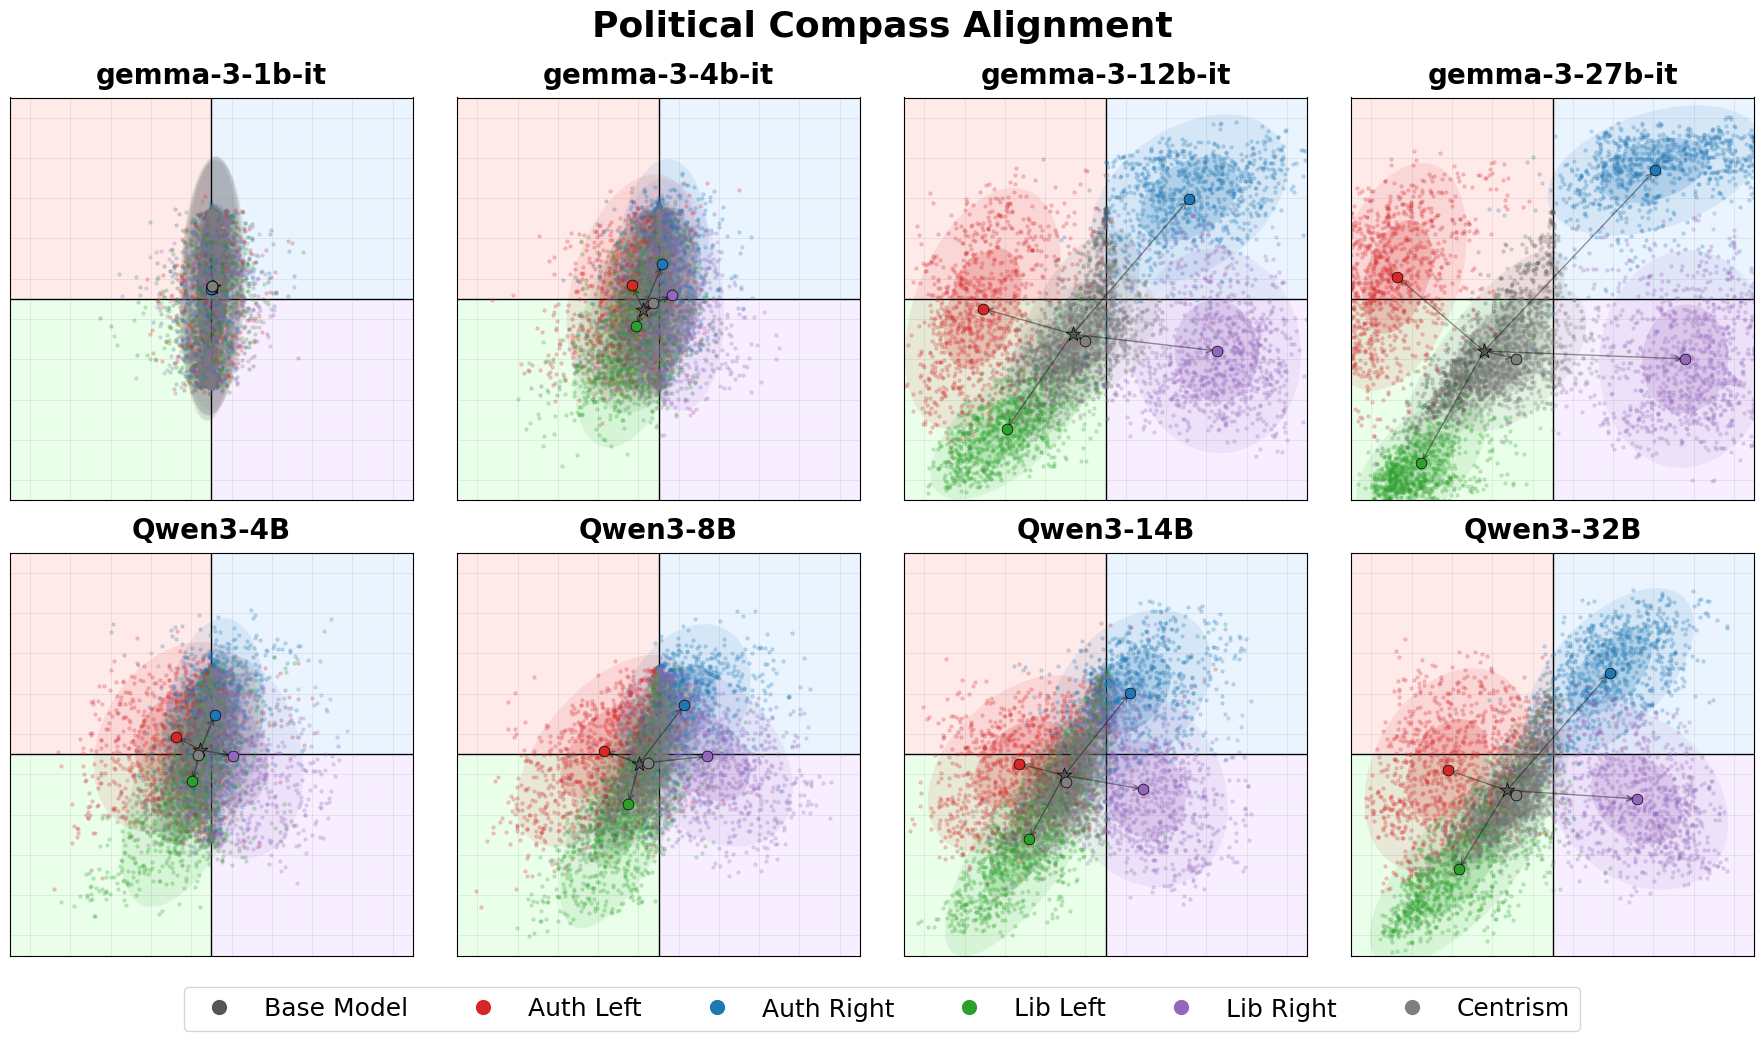

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

# ==========================================
# CONFIGURATION
# ==========================================
RESULTS_DIR = "output/mcq-v1-300/results/"
PARAMS_PATH = "scorer.npz"
PLOTS_OUTPUT_DIR = "output/mcq-v1-300/plots/"

FINAL_MODELS = [
    # Gemma-3 Family
    'gemma-3-1b-it',
    'gemma-3-4b-it',
    'gemma-3-12b-it',
    'gemma-3-27b-it',
    # Qwen-3 Family
    'Qwen3-4B',
    'Qwen3-8B',
    'Qwen3-14B',
    'Qwen3-32B',
]

TARGET_IDEOLOGIES = ["base", "authoritarian_left", "authoritarian_right", "libertarian_left", "libertarian_right", "centrism"]
DISPLAY_NAMES = {
    "base": "Base Model",
    "authoritarian_left": "Auth Left",
    "authoritarian_right": "Auth Right",
    "libertarian_left": "Lib Left",
    "libertarian_right": "Lib Right",
    "centrism": "Centrism"
}
COLORS = {
    "Base Model": "#555555",
    "Auth Left":  "#d62728",
    "Auth Right": "#1f77b4",
    "Lib Left":   "#2ca02c",
    "Lib Right":  "#9467bd",
    "Centrism":   "#7f7f7f"
}

# ==========================================
# HELPER FUNCTIONS
# ==========================================

def confidence_ellipse(x, y, ax, n_std=1.0, facecolor='none', **kwargs):
    if x.size != y.size:
        raise ValueError("x and y must be the same size")

    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    
    # Eigendecomposition gives correct axis orientation
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    
    # Sort by descending eigenvalue
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    
    # Angle of the largest eigenvector
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    
    # Width and height are 2 * n_std * sqrt(eigenvalue)
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    
    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=angle,
        facecolor=facecolor,
        **kwargs
    )
    
    return ax.add_patch(ellipse)

def draw_background(ax):
    ax.set_xlim(-10, 10); ax.set_ylim(-10, 10); ax.set_aspect('equal')
    ax.add_patch(patches.Rectangle((-10, 0), 10, 10, fc='#ff3333', alpha=0.1)) 
    ax.add_patch(patches.Rectangle((0, 0), 10, 10, fc='#3399ff', alpha=0.1))   
    ax.add_patch(patches.Rectangle((-10, -10), 10, 10, fc='#33ff33', alpha=0.1)) 
    ax.add_patch(patches.Rectangle((0, -10), 10, 10, fc='#b366ff', alpha=0.1))   
    ax.axhline(0, color='black', lw=1); ax.axvline(0, color='black', lw=1)
    for i in range(-9, 10, 2):
        if i != 0:
            ax.axhline(i, color='gray', lw=0.5, alpha=0.2)
            ax.axvline(i, color='gray', lw=0.5, alpha=0.2)
    ax.set_xticks([]); ax.set_yticks([])

# ==========================================
# DATA PROCESSING
# ==========================================

def calculate_scores_with_debias(df, W_ECON, W_SOC, B_ECON, B_SOC, NUM_QUESTIONS):
    econ_scores = np.zeros(len(df)) + B_ECON
    soc_scores = np.zeros(len(df)) + B_SOC
    is_reversed = df['perm_id'].isin([2, 3]).values
    
    for q_idx in range(NUM_QUESTIONS):
        cols = [f"q{q_idx}_prob_ans{a}" for a in range(4)]
        if not all(c in df.columns for c in cols): continue
        probs = df[cols].values
        corrected_probs = probs.copy()
        corrected_probs[is_reversed] = probs[is_reversed][:, ::-1]
        econ_scores += np.dot(corrected_probs, W_ECON[q_idx, :])
        soc_scores += np.dot(corrected_probs, W_SOC[q_idx, :])
        
    df['score_econ'] = econ_scores
    df['score_soc'] = soc_scores
    return df


# ==========================================
# STYLE CONTROLS (Tweak these for layout)
# ==========================================
FONT_SIZE_SUPTITLE = 26
FONT_SIZE_TITLE = 20
FONT_SIZE_LEGEND = 18

# Spacing parameters
W_SPACE = -0.3  # Horizontal space between plots (lower = closer)
H_SPACE = 0.13  # Vertical space between rows
PLOT_MARGIN_TOP = 0.90    # Space for the main title
PLOT_MARGIN_BOTTOM = 0.12 # Space for the legend
PLOT_MARGIN_LEFT = 0.05
PLOT_MARGIN_RIGHT = 0.95

# ==========================================
# HELPER FUNCTIONS (No changes here)
# ==========================================

def draw_background(ax):
    ax.set_xlim(-10, 10); ax.set_ylim(-10, 10); ax.set_aspect('equal')
    ax.add_patch(patches.Rectangle((-10, 0), 10, 10, fc='#ff3333', alpha=0.1)) 
    ax.add_patch(patches.Rectangle((0, 0), 10, 10, fc='#3399ff', alpha=0.1))   
    ax.add_patch(patches.Rectangle((-10, -10), 10, 10, fc='#33ff33', alpha=0.1)) 
    ax.add_patch(patches.Rectangle((0, -10), 10, 10, fc='#b366ff', alpha=0.1))   
    ax.axhline(0, color='black', lw=1); ax.axvline(0, color='black', lw=1)
    # Optional: Add Quadrant Labels if desired
    # ax.text(-5, 5, "Auth Left", alpha=0.2, ha='center', va='center', fontsize=8)
    for i in range(-9, 10, 2):
        if i != 0:
            ax.axhline(i, color='gray', lw=0.5, alpha=0.2)
            ax.axvline(i, color='gray', lw=0.5, alpha=0.2)
    ax.set_xticks([]); ax.set_yticks([])

# ==========================================
# DATA PROCESSING
# ==========================================

def process_and_plot_grid():
    # 1. Load Parameters
    try:
        loaded_params = np.load(PARAMS_PATH)
        W_ECON, W_SOC = loaded_params['weights_economic'], loaded_params['weights_social']
        B_ECON, B_SOC = loaded_params['bias_economic'], loaded_params['bias_social']
        NUM_QUESTIONS = W_ECON.shape[0]
    except Exception as e:
        print(f"Error loading parameters: {e}"); return

    # 2. Load Data
    all_files = [os.path.join(RESULTS_DIR, f) for f in os.listdir(RESULTS_DIR) if f.endswith(".csv")]
    if not all_files: print("No CSV files found."); return
        
    df_raw = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)
    
    # 3. Filter and Calculate
    df = df_raw[df_raw['model'].isin(FINAL_MODELS)].copy()
    df = calculate_scores_with_debias(df, W_ECON, W_SOC, B_ECON, B_SOC, NUM_QUESTIONS)
    df['Label'] = df['ideology'].map(DISPLAY_NAMES)


    # 4. Create Grid Plot
    fig, axes = plt.subplots(2, 4, figsize=(22, 11)) # Slightly wider figure
    axes = axes.flatten()

    for i, model_name in enumerate(FINAL_MODELS):
        ax = axes[i]
        draw_background(ax)
        
        # INCREASED FONT SIZE: Subplot Titles
        ax.set_title(model_name, fontsize=FONT_SIZE_TITLE, fontweight='bold', pad=10)
        
        model_df = df[df['model'] == model_name]
        if model_df.empty:
            ax.text(0, 0, "No Data", ha='center')
            continue

        # Get Base Model position
        base_subset = model_df[model_df['Label'] == 'Base Model']
        bx, by = (base_subset['score_econ'].mean(), base_subset['score_soc'].mean()) if not base_subset.empty else (0,0)

        for label, color in COLORS.items():
            subset = model_df[model_df['Label'] == label]
            if subset.empty: continue
            
            x, y = subset['score_econ'].values, subset['score_soc'].values
            m_x, m_y = x.mean(), y.mean()

            ax.scatter(x, y, color=color, s=5, alpha=0.2, zorder=2)
            
            if len(subset) > 2:
                confidence_ellipse(x, y, ax, n_std=1.0, facecolor=color, alpha=0.2, zorder=1)
                confidence_ellipse(x, y, ax, n_std=2.0, facecolor=color, alpha=0.1, zorder=1)
            
            ax.scatter(m_x, m_y, color=color, s=120 if label=="Base Model" else 60, 
                       marker='*' if label=="Base Model" else 'o', edgecolors='black', linewidths=0.5, zorder=5)
            
            if label != "Base Model":
                ax.annotate("", xy=(m_x, m_y), xytext=(bx, by),
                            arrowprops=dict(arrowstyle="->", color='black', lw=1.0, alpha=0.4), zorder=3)

    # ADJUST SPACING: Use subplots_adjust instead of tight_layout
    plt.subplots_adjust(
        left   = PLOT_MARGIN_LEFT, 
        right  = PLOT_MARGIN_RIGHT, 
        top    = PLOT_MARGIN_TOP, 
        bottom = PLOT_MARGIN_BOTTOM,
        wspace = W_SPACE, 
        hspace = H_SPACE
    )

    # INCREASED FONT SIZE: Shared Legend
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=12, label=l) 
               for l, c in COLORS.items()]
    fig.legend(handles=handles, loc='lower center', ncol=6, 
               fontsize=FONT_SIZE_LEGEND, frameon=True, bbox_to_anchor=(0.5, 0.04))
    
    # INCREASED FONT SIZE: Super Title
    plt.suptitle("Political Compass Alignment", fontsize=FONT_SIZE_SUPTITLE, fontweight='bold')
    
    plt.savefig(os.path.join(PLOTS_OUTPUT_DIR, "Political_Compass_Alignment.png"), dpi=200, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    process_and_plot_grid()